In [3]:
from pyspark.sql import SparkSession
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Stop SparkSession jika ada yang aktif
try:
    spark.stop()
except:
    pass

# Buat spark session
spark = SparkSession.builder \
    .appName("ChurnPredictionEDA") \
    .config("spark.driver.memory", "8g") \
    .config("spark.driver.maxResultSize", "4g") \
    .getOrCreate()

In [17]:
import pandas as pd
import os

# 1. SETUP PATH (Sama seperti yang berhasil tadi)
current_dir = os.getcwd()
target_path = os.path.join(current_dir, "data", "master_feature_table_3.parquet")


try:
    master_table_pd = pd.read_parquet(target_path)
    print("-" * 30)
    print(master_table_pd.head())
    print("-" * 30)
    print(master_table_pd.info())
    
except Exception as e:
    print(e)

------------------------------
                                           msno  is_churn  city  \
0  ++4RuqBw0Ss6bQU4oMxaRlbBPoWzoEiIZaxPM04Y4+U=         0     1   
1  +/HS8LzrRGXolKbxRzDLqrmwuXqPOYixBIPXkyNcKNI=         0     0   
2  +/g9O3USecrC8npzaFHXW/2XJ7fB80SineiUoCg7M6o=         0     0   
3  +/namlXq+u3izRjHCFJV4MgqcXcLidZYszVsROOq/y4=         0    15   
4  +0/X9tkmyHyet9X80G6GTrDFHnJqvai8d1ZPhayT0os=         0     9   

        age_group  registered_via  membership_duration_days  \
0         Unknown               7                       991   
1            None               0                         0   
2            None               0                         0   
3  26-35 (Dewasa)               9                      3954   
4  26-35 (Dewasa)               9                      4749   

   total_transactions  total_payment_plan_days  avg_discount  \
0                  27                      780     -4.777778   
1                  11                      330      0.00000

In [19]:
# master_table_path = "data/master_feature_table_3.parquet"

# print(f"Memuat data dari {master_table_path}...")
# master_table_spark = spark.read.parquet(master_table_path)
# #master_table_spark.cache()

# # print schema
# print("Skema master_table:")
# master_table_spark.printSchema()

# # convert to Pandas DataFrame for visualization
# print("\nMengonversi ke Pandas DataFrame")
# master_table_pd = master_table_spark.toPandas()

# # display data
# display(master_table_pd.head())


In [20]:
print("Data Schema:")
print(master_table_pd.info())

Data Schema:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1082190 entries, 0 to 1082189
Data columns (total 22 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   msno                       1082190 non-null  object 
 1   is_churn                   1082190 non-null  int32  
 2   city                       1082190 non-null  int32  
 3   age_group                  961431 non-null   object 
 4   registered_via             1082190 non-null  int32  
 5   membership_duration_days   1082190 non-null  int32  
 6   total_transactions         1082190 non-null  int64  
 7   total_payment_plan_days    1082190 non-null  int64  
 8   avg_discount               1082190 non-null  float64
 9   count_auto_renew           1082190 non-null  int64  
 10  count_cancel               1082190 non-null  int64  
 11  last_transaction_date      1082190 non-null  int32  
 12  last_expiry_date           1082190 non-null  int32  
 13 

Memulai visualisasi demografi...


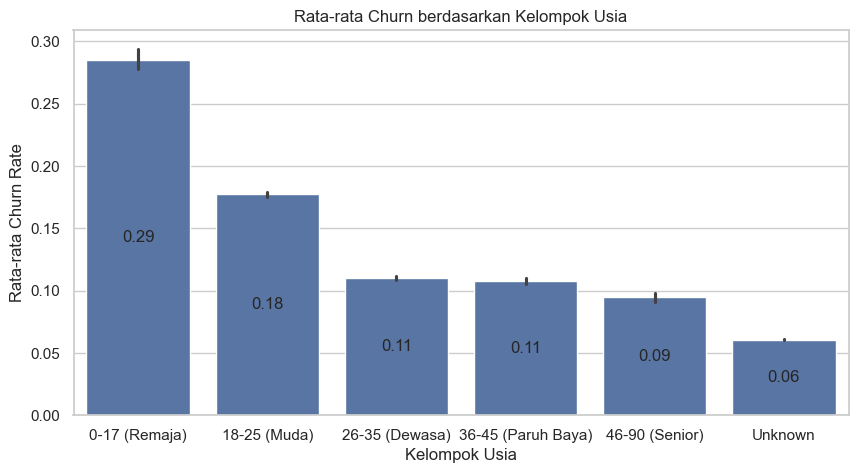

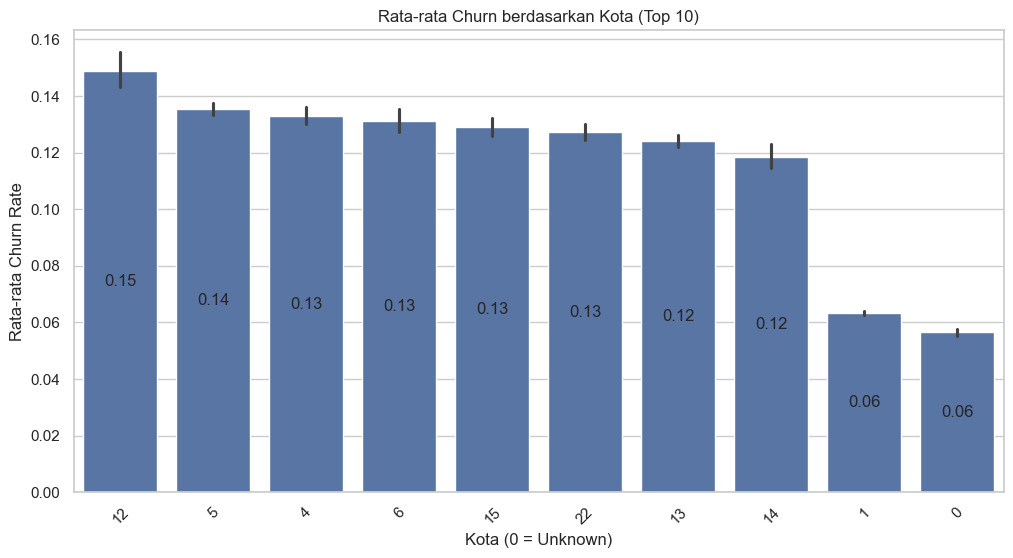

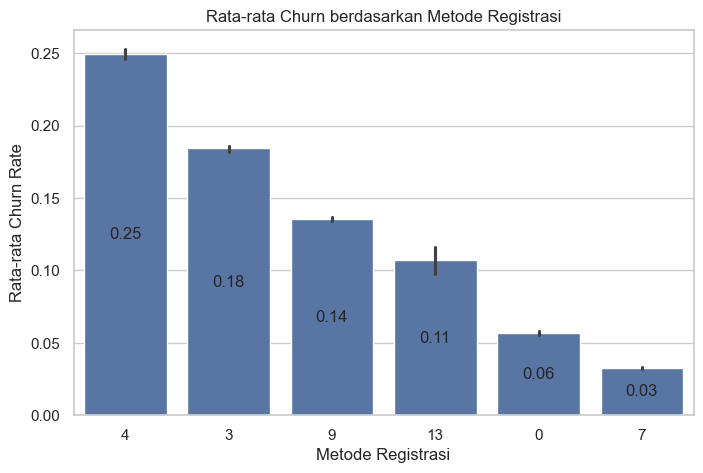

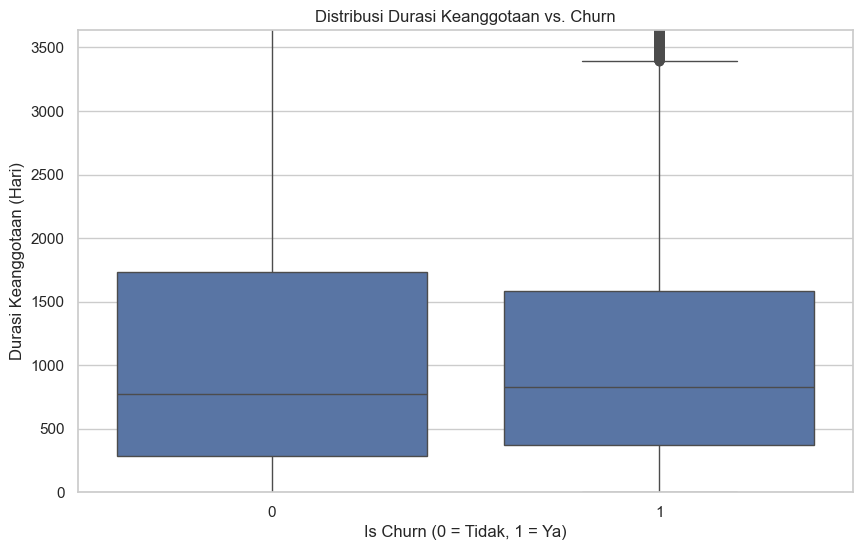

Visualisasi demografi selesai.


In [7]:
print("Memulai visualisasi demografi...")

#TIDAK PERLU LAGI ISI NULL DI MASTER TABLE KARENA SUDAH DILAKUKAN DI FEATURE ENGINEERING
# Isi nilai None/NULL sebelum plotting
# Ganti None di 'age_group' (string) dengan 'Unknown'
master_table_pd['age_group'] = master_table_pd['age_group'].fillna('Unknown')
# Ganti None di 'city' (int) dengan 0 (bisa dianggap kategori 'Unknown/Lainnya')
master_table_pd['city'] = master_table_pd['city'].fillna(0)
# Ganti None di 'registered_via' (int) dengan 0 (bisa dianggap kategori 'Unknown/Lainnya')
master_table_pd['registered_via'] = master_table_pd['registered_via'].fillna(0)

# Plot 1: Rata-rata Churn berdasarkan Kelompok Usia (age_group)
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=master_table_pd, 
    x='age_group', 
    y='is_churn', 
    # sort dari terbesar 
    order=master_table_pd.groupby('age_group')['is_churn'].mean().sort_values(ascending=False).index
)

ax.bar_label(ax.containers[0], fmt='%.2f', label_type='center')

plt.title('Rata-rata Churn berdasarkan Kelompok Usia')
plt.ylabel('Rata-rata Churn Rate')
plt.xlabel('Kelompok Usia')

# save gambar
plt.savefig("age_group_vs_churn.png", bbox_inches='tight')
plt.show()

# Plot 2: Rata-rata Churn berdasarkan Kota (city)
plt.figure(figsize=(12, 6))
# 10 kota dengan pengguna terbanyak
top_cities = master_table_pd['city'].value_counts().nlargest(10).index

# Buat kolom baru untuk plot city top 10
plot_data_top10 = master_table_pd[master_table_pd['city'].isin(top_cities)].copy()
# sort
churn_rate_order = plot_data_top10.groupby('city')['is_churn'].mean().sort_values(ascending=False).index
ax2 = sns.barplot(data=plot_data_top10, x='city', y='is_churn', order=churn_rate_order)
ax2.bar_label(ax2.containers[0], fmt='%.2f', label_type='center')
plt.title('Rata-rata Churn berdasarkan Kota (Top 10)')
plt.ylabel('Rata-rata Churn Rate')
plt.xlabel('Kota (0 = Unknown)')
plt.xticks(rotation=45)
# save gambar
plt.savefig("city_vs_churn2.png", bbox_inches='tight')
plt.show()

# Plot 3: Rata-rata Churn berdasarkan Metode Registrasi (registered_via)
plt.figure(figsize=(8, 5))
# Urutkan berdasarkan rata-rata churn tertingi ke terendah
reg_order = master_table_pd.groupby('registered_via')['is_churn'].mean().sort_values(ascending=False).index
ax3=sns.barplot(data=master_table_pd, x='registered_via', y='is_churn', order=reg_order)
ax3.bar_label(ax3.containers[0], fmt='%.2f', label_type='center')
plt.title('Rata-rata Churn berdasarkan Metode Registrasi')
plt.ylabel('Rata-rata Churn Rate')
plt.xlabel('Metode Registrasi')
# save gambar
plt.savefig("registered_via_vs_churn2.png", bbox_inches='tight')
plt.show()

# Plot 4: Distribusi Durasi Keanggotaan (membership_duration_days) vs. Churn
plt.figure(figsize=(10, 6))
# Ganti None di kolom dengan 0
master_table_pd['membership_duration_days'] = master_table_pd['membership_duration_days'].fillna(0)

sns.boxplot(data=master_table_pd, x='is_churn', y='membership_duration_days')
plt.title('Distribusi Durasi Keanggotaan vs. Churn')
plt.xlabel('Is Churn (0 = Tidak, 1 = Ya)')
plt.ylabel('Durasi Keanggotaan (Hari)')
# batasi sumbu y ke quantil 95% agar outlier spy plot ga rusak
q95 = master_table_pd['membership_duration_days'].quantile(0.95)
# pastiin q95 tidak 0, jika ya, beri batas atas default
if q95 == 0:
    q95 = master_table_pd['membership_duration_days'].max()
    
plt.ylim(0, q95)

plt.savefig("membership_duration_vs_churn.png", bbox_inches='tight')
plt.show()

print("Visualisasi demografi selesai.")

## Interpretasi Demografi
#### Plot 1: Rata-rata Churn based on age_group
Grup "Unknown" justru merupakan salah satu grup yang paling loyal, dengan churn rate terendah kedua (sekitar 6%). Pengguna remaja (0-17) adalah yang paling berisiko untuk churn (~28%), diikuti oleh grup "18-25 (Muda)" (~17.5%).

#### Plot 2: Rata-rata Churn based on city
Terdapat variasi, namun yang paling menonjol adalah Kota '12' sebagai kota dengan risiko churn tertinggi. Sebaliknya, Kota '0' (Unknown) dan Kota '1' adalah dua grup yang paling loyal (churn rate terendah, di kisaran 6%).

#### Plot 3: Rata-rata Churn based on registred_via
Metode '4' menghasilkan pengguna yang paling mudah churn. Sebaliknya, metode '7' menghasilkan pengguna yang paling loyal. Metode '3' juga berisiko tinggi (~18%).

#### Plot 4: Distribusi Membership_duration_days
Durasi Keanggotaan BUKANLAH prediktor yang baik untuk churn. Pengguna yang churn dan yang loyal memiliki profil durasi keanggotaan yang hampir identik. Ini membatalkan asumsi awal kita(smkn lama smkn loyal) dan sangat penting untuk feature selection nanti.

Memulai visualisasi transaksi...


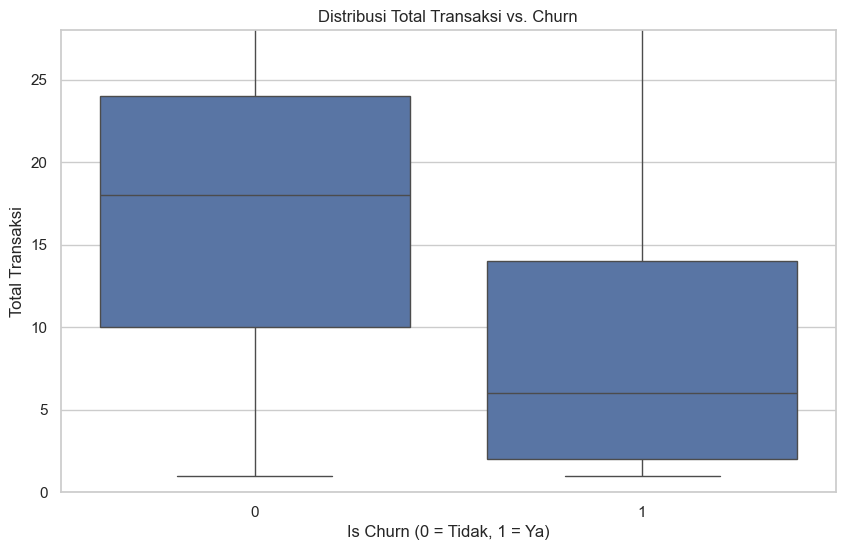

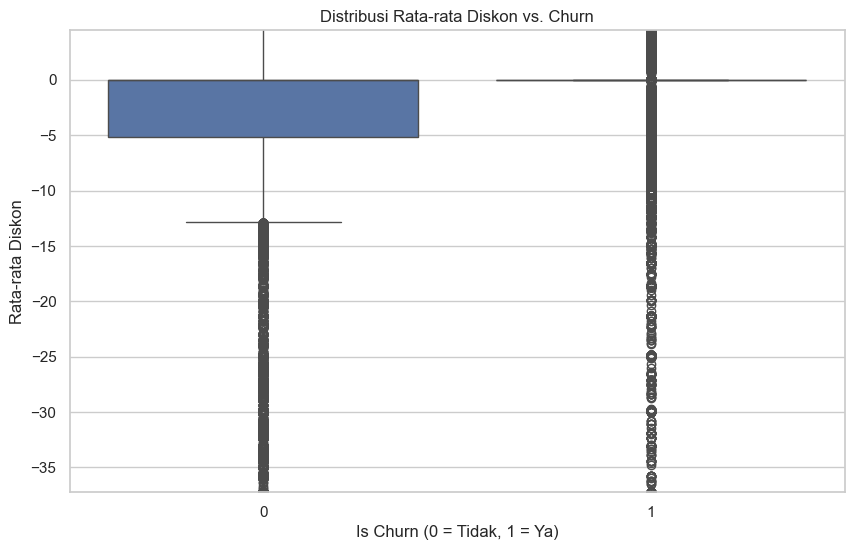

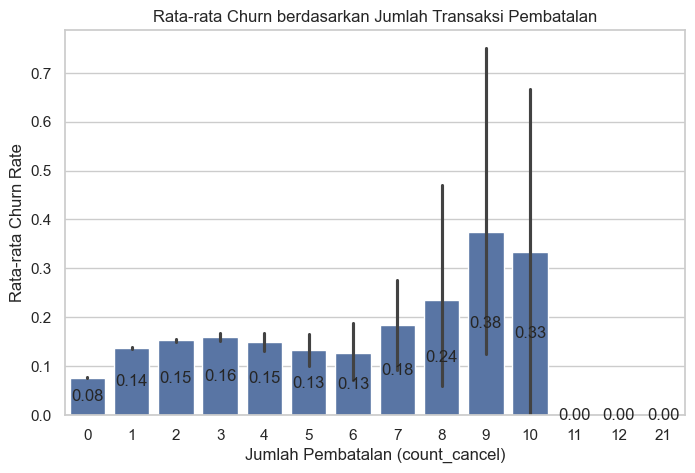

In [8]:
print("Memulai visualisasi transaksi...")

# Plot 1: Distribusi Total Transaksi (total_transactions) vs. Churn 
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_table_pd, x='is_churn', y='total_transactions')
plt.title('Distribusi Total Transaksi vs. Churn')
plt.xlabel('Is Churn (0 = Tidak, 1 = Ya)')
plt.ylabel('Total Transaksi')
# Batasi sumbu y ke quantil 95%
plt.ylim(0, master_table_pd['total_transactions'].quantile(0.95))
plt.show()

# Plot 2: Distribusi Rata-rata Diskon (avg_discount) vs. Churn 
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_table_pd, x='is_churn', y='avg_discount')
plt.title('Distribusi Rata-rata Diskon vs. Churn')
plt.xlabel('Is Churn (0 = Tidak, 1 = Ya)')
plt.ylabel('Rata-rata Diskon')
# Batasi sumbu y agar lebih jelas
plt.ylim(master_table_pd['avg_discount'].quantile(0.05), master_table_pd['avg_discount'].quantile(0.95))
plt.show()

# Plot 3: Rata-rata Churn berdasarkan Jumlah Pembatalan (count_cancel) 
plt.figure(figsize=(8, 5))
ax4 = sns.barplot(data=master_table_pd, x='count_cancel', y='is_churn')
ax4.bar_label(ax4.containers[0], fmt='%.2f', label_type='center')
plt.title('Rata-rata Churn berdasarkan Jumlah Transaksi Pembatalan')
plt.ylabel('Rata-rata Churn Rate')
plt.xlabel('Jumlah Pembatalan (count_cancel)')
plt.show()

## Interpretasi Transactions
### Plot 5: Distribusi total transactions
Pengguna yang churn memiliki jumlah transaksi jauh lbh dikit. Pengguna yang loyal memiliki median transaksi lebih tinggi dan sebaran yang lebih luas (banyak transaksi berkali"). Jadi semakin sering membayar, semakin loyal mrk.

### Plot 6: Distribusi avg discount
Distribusinya berbeda, box plot untuk yang tidak churn punya rentang sebaran yg lbh lebar, terutama ke arah nilai negatif(actual_amount_paid > plan_list_price, mungkin upgrade (?)). Pengguna yg churn distribusinya lebih sempit dan terpusat di 0.

### Plot 7: Rata-rata Churn based on count_cancel
Plot ini menunjukkan sebuah tren:
- Baseline (count_cancel = 0): Pengguna yang tidak pernah membatalkan transaksi memiliki churn rate terendah, yaitu di bawah 0.10 (sekitar 7.5%). Ini paling loyal.

- Satu Kali Batal (count_cancel = 1): Begitu pengguna batalin satu kali saja, churn rate mereka langsung naik dua kali lipat jadi ~15%.

- Tren Kenaikan (count_cancel > 1): Semakin sering seseorang membatalkan (2 kali, 3 kali, 7 kali), rata-rata churn rate mereka juga ikut naik secara bertahap.

- Puncak (count_cancel 8-10): Churn rate melonjak drastis pada pengguna yang batalin 8, 9, atau 10 kali, mencapai puncaknya di 33% - 37%. (error bar yang panjang di angka 9 dan 10 menunjukkan jumlah pengguna di grup lebih dikit, sehingga variasinya besar, tapi rata-ratanya tetap sangat tinggi).


Memulai visualisasi perilaku log...


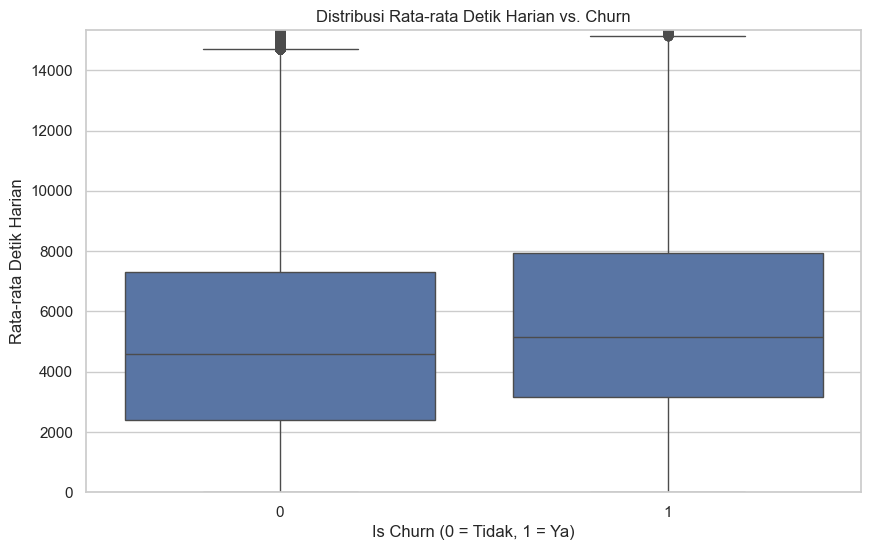

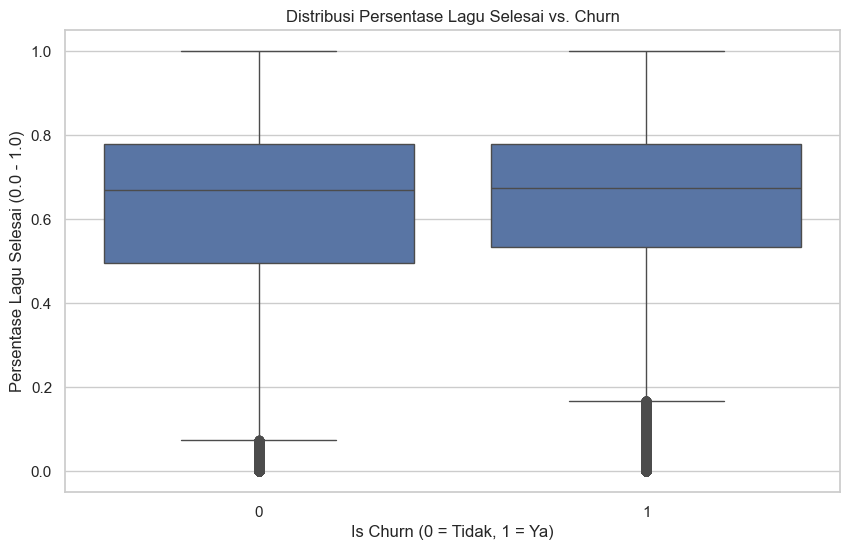

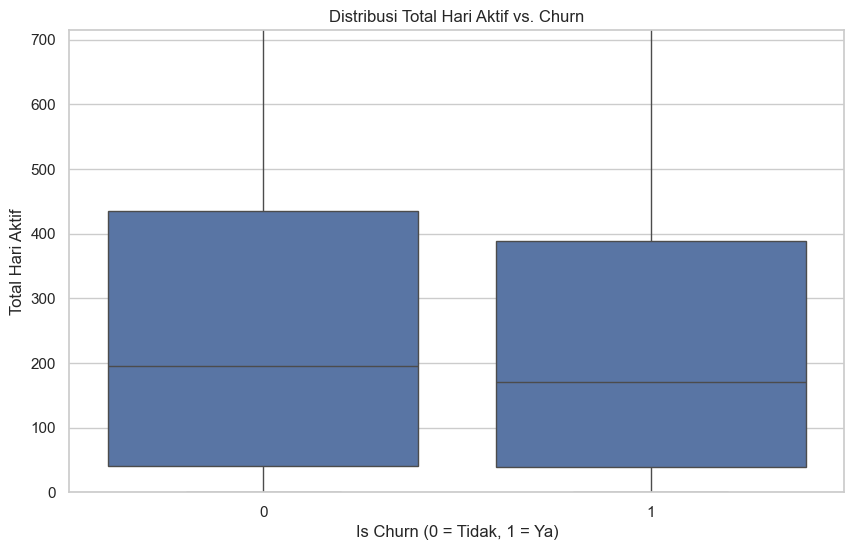

In [9]:
print("Memulai visualisasi perilaku log...")

# Plot 1: Distribusi Rata-rata Detik Harian (avg_daily_secs) vs. Churn
plt.figure(figsize=(10, 6))

sns.boxplot(data=master_table_pd, x='is_churn', y='avg_daily_secs') 
plt.title('Distribusi Rata-rata Detik Harian vs. Churn')
plt.xlabel('Is Churn (0 = Tidak, 1 = Ya)')
plt.ylabel('Rata-rata Detik Harian')
# Batasi sumbu y ke quantil 95%
plt.ylim(0, master_table_pd['avg_daily_secs'].quantile(0.95))
plt.show()

# Plot 2: Distribusi Persentase Lagu Selesai (percent_songs_completed) vs. Churn
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_table_pd, x='is_churn', y='percent_songs_completed')
plt.title('Distribusi Persentase Lagu Selesai vs. Churn')
plt.xlabel('Is Churn (0 = Tidak, 1 = Ya)')
plt.ylabel('Persentase Lagu Selesai (0.0 - 1.0)')
plt.show()

# Plot 3: Distribusi Total Hari Aktif (total_active_days) vs. Churn
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_table_pd, x='is_churn', y='total_active_days')
plt.title('Distribusi Total Hari Aktif vs. Churn')
plt.xlabel('Is Churn (0 = Tidak, 1 = Ya)')
plt.ylabel('Total Hari Aktif')
# Batasi sumbu y ke quantil 95%
plt.ylim(0, master_table_pd['total_active_days'].quantile(0.95))
plt.show()

## Interpretasi Log
### Plot 8: Rata-data detik harian
Distribusi kedua grup ini hampir mirip. Pengguna yang churn justru punya rata-rata (median) waktu dengar harian yang sedikit lebih lama. Ini membatalkan asumsi kita. Fitur ini sepertinya memiliki sinyal yang lemah atau bahkan berlawanan.

### Plot 8: Rata-data detik harian
Fitur percent_songs_completed tampaknya tidak memiliki sinyal prediktif sama sekali. Baik pengguna loyal maupun yang churn memiliki kebiasaan skip lagu yang sangat mirip.

### Plot 9: Total active days
Ada sinyal yang lemah di sini. Pengguna yang churn cenderung memiliki hari aktif yang sedikit lebih sedikit, tetapi distribusinya sangat tumpang tindih (overlapping) dengan pengguna loyal.

In [10]:
master_table_path_3 = "data/master_feature_table_3.parquet"

print(f"Memuat data dari {master_table_path_3}...")
master_table_spark_3 = spark.read.parquet(master_table_path_3)
try:
    # 1. Hapus versi LAMA (jika ada) dari memori
    master_table_spark_3.unpersist() 
    print("Cache master_table_spark_3 lama berhasil dihapus.")
except NameError:
    print("Cache master_table_spark_3 belum ada, lanjut membuat baru.")
    
master_table_spark_3.cache()

# print schema
print("Skema master_table:")
master_table_spark_3.printSchema()

# convert to Pandas DataFrame for visualization
print("\nMengonversi ke Pandas DataFrame")
master_table_pd_3 = master_table_spark_3.toPandas()

# display data
display(master_table_pd_3.head())

Memuat data dari data/master_feature_table_3.parquet...
Cache master_table_spark_3 lama berhasil dihapus.
Skema master_table:
root
 |-- msno: string (nullable = true)
 |-- is_churn: integer (nullable = true)
 |-- city: integer (nullable = true)
 |-- age_group: string (nullable = true)
 |-- registered_via: integer (nullable = true)
 |-- membership_duration_days: integer (nullable = true)
 |-- total_transactions: long (nullable = true)
 |-- total_payment_plan_days: long (nullable = true)
 |-- avg_discount: double (nullable = true)
 |-- count_auto_renew: long (nullable = true)
 |-- count_cancel: long (nullable = true)
 |-- last_transaction_date: integer (nullable = true)
 |-- last_expiry_date: integer (nullable = true)
 |-- days_since_last_activity: integer (nullable = true)
 |-- total_secs_last_30d: double (nullable = true)
 |-- active_days_last_30d: long (nullable = true)
 |-- total_secs_last_90d: double (nullable = true)
 |-- active_days_last_90d: long (nullable = true)
 |-- activity_r

,msno,is_churn,city,age_group,registered_via,membership_duration_days,total_transactions,total_payment_plan_days,avg_discount,count_auto_renew,...,last_expiry_date,days_since_last_activity,total_secs_last_30d,active_days_last_30d,total_secs_last_90d,active_days_last_90d,activity_ratio_secs,percent_complete_last_30d,lifetime_active_days,lifetime_unq_songs
0,++xbPSy/npsr5jYR8uiyRh2jsZ7IdOD5gCGx2BzYrkM=,0,22,18-25 (Muda),9,2541,21,855,-7.095238,0,...,20170831,0,154958.330,27,401382.140,82,0.628829,0.810705,748,23171
1,+/RgFgqC+fsCKMQCBdtcwR4Jj0zjTDW0CSq7C/9vvoI=,0,13,18-25 (Muda),9,3113,21,603,-7.095238,21,...,20170511,0,506308.559,30,1842344.768,90,0.378963,0.893627,778,45464
2,+0fgBZzlFyXZqtdTd2scisNTu/Aq/PkC2SgCnFzNkHA=,0,13,36-45 (Paruh Baya),7,2101,29,840,-5.137931,29,...,20170424,0,58054.556,10,115734.991,37,1.006486,0.238158,447,9622
3,+1kZsXKKkkySy0txWHp+prLJNjIPpRven+Xa3f0Y+qw=,0,15,36-45 (Paruh Baya),9,817,22,604,-0.045455,20,...,20170415,0,31621.768,12,293868.201,60,0.120580,0.913580,605,9135
4,+26LIV+I6MBmFPH7zNaJ0xnerqm0AfG45bomQLucXUc=,0,4,0-17 (Remaja),13,132,5,150,0.000000,5,...,20170418,3,38066.760,9,101783.136,35,0.597441,0.612440,57,662


Memulai visualisasi perilaku log


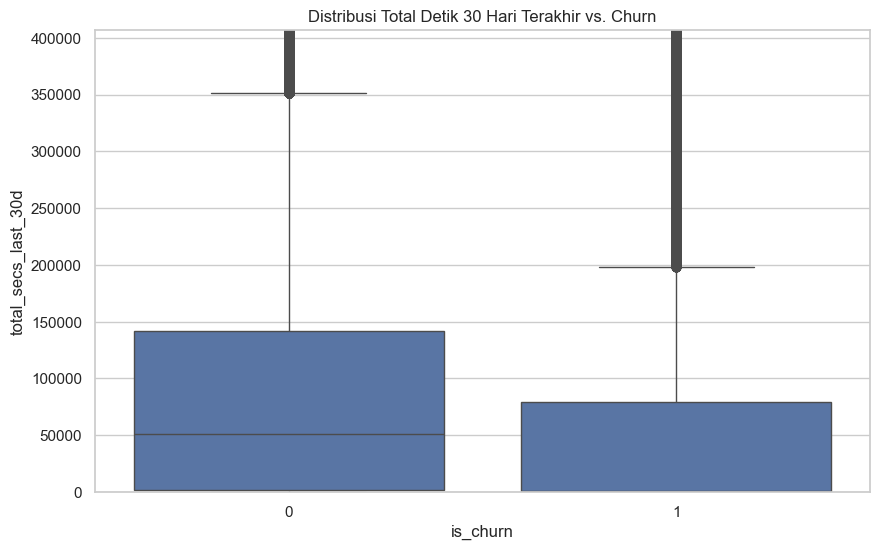

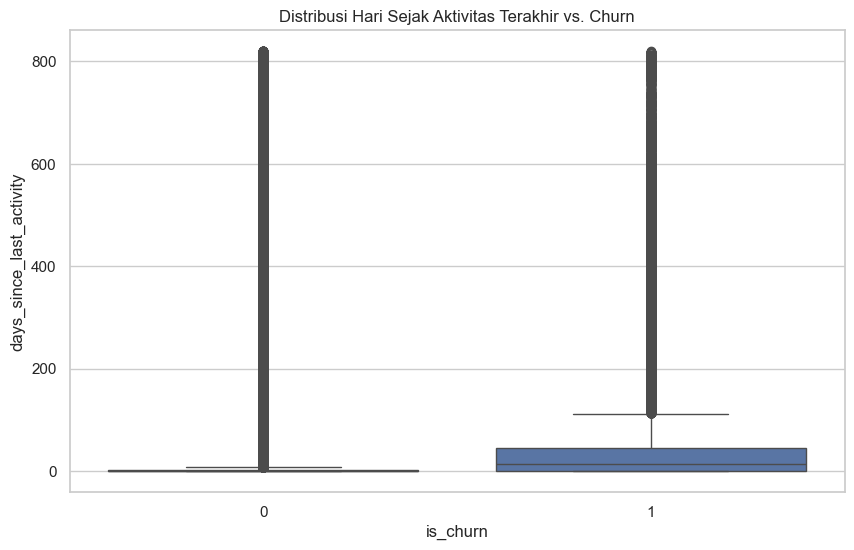

KeyboardInterrupt: 

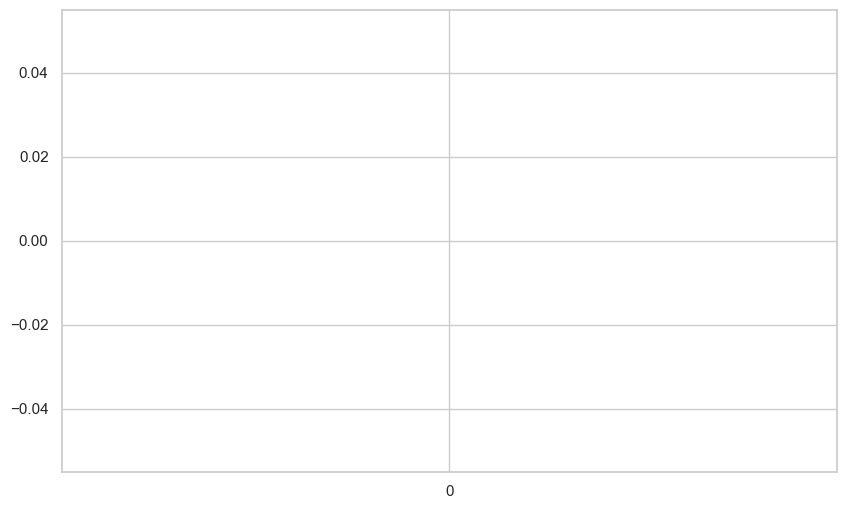

In [11]:
# Features lbh fokus ke recency + perilaku terbary (last 30 days)
print("Memulai visualisasi perilaku log")

# Plot 1: Distribusi Total Detik 30 Hari Terakhir vs. Churn
# Hipotesis: Pengguna churn akan memiliki total detik yang sangat rendah.
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_table_pd_3, x='is_churn', y='total_secs_last_30d')
plt.title('Distribusi Total Detik 30 Hari Terakhir vs. Churn')
# Batasi outlier agar plot utama lebih jelas
q95 = master_table_pd_3['total_secs_last_30d'].quantile(0.95)
if q95 == 0: q95 = master_table_pd_3['total_secs_last_30d'].max()
plt.ylim(0, q95) 
plt.show()

# Plot 2: Distribusi Hari Sejak Aktivitas Terakhir vs. Churn
# Hipotesis: Pengguna churn sudah lama tidak aktif (angka tinggi).
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_table_pd_3, x='is_churn', y='days_since_last_activity')
plt.title('Distribusi Hari Sejak Aktivitas Terakhir vs. Churn')
plt.show()

# Plot 3: Distribusi Total Hari Aktif 30 Hari Terakhir vs. Churn
# Hipotesis: Pengguna churn memiliki hari aktif yang sangat sedikit (mendekati 0).
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_table_pd_3, x='is_churn', y='active_days_last_30d')
plt.title('Distribusi Total Hari Aktif 30 Hari Terakhir vs. Churn')
plt.show()

# Plot 4: Distribusi Persentase Lagu Selesai 30 Hari Terakhir vs. Churn
# Hipotesis: Pengguna churn lebih sering skip lagu BARU-BARU INI (nilai lebih rendah).
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_table_pd_3, x='is_churn', y='percent_complete_last_30d')
plt.title('Distribusi Persentase Lagu Selesai 30 Hari Terakhir vs. Churn')
plt.ylabel('Persentase Lagu Selesai (0.0 - 1.0)')
plt.show()

# Plot 5: Distribusi Rasio Aktivitas (Tren) vs. Churn
# Hipotesis: Pengguna churn menunjukkan penurunan aktivitas (rasio < 1.0).
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_table_pd_3, x='is_churn', y='activity_ratio_secs')
plt.title('Distribusi Rasio Aktivitas (30d vs 90-30d) vs. Churn')
plt.ylabel('Rasio Aktivitas (Tren)')
# Batasi sumbu y karena rasio bisa sangat besar/kecil. Fokus di antara 0 dan 3.
plt.ylim(0, master_table_pd_3['activity_ratio_secs'].quantile(0.90)) 
plt.show()

Hasil plot ini better dari yg sblmnya yang lifetime (lbh fokus ke recency dan perilaku terbaru (last 30 days))

# Plot total secs last 30 days
- Churn = 0 (Loyal): Box plot (kotaknya) jauh lebih tinggi. Median (garis tengah) ada di sekitar 50.000 detik. Ini adalah pengguna yang sangat aktif di bulan terakhir.

- Churn = 1: Box plot jauh lebih rendah. Median-nya sangat dekat dengan 0 (mungkin sekitar 5.000 detik). Ini berarti 50% dari pengguna yang churn hampir tidak mendengarkan apa pun dalam 30 hari terakhir.

--> penurunan drastim dlm volume mendengarkan di 30 hari terakhir (prediktor kuat churn)

# Plot hari sejak last activity
- Churn = 0 (Loyal): Kotaknya "gepeng" atau kolaps di angka 0. Ini berarti mayoritas (setidaknya 75%) pengguna loyal aktif hingga hari terakhir (atau 1-2 hari terakhir) dari periode data.

- Churn = 1: Kotaknya jelas terlihat dan lebih tinggi. Mediannya ada di sekitar 25-30 hari. Ini berarti 50% pengguna yang churn sudah tidak aktif selama hampir sebulan sebelum churn terdeteksi.

--> pengguna churn "hilang" terlebih dahulu, predikor oke

# plot total days active last 30 days
- Churn = 0 (Loyal): Median hari aktif tinggi, sekitar 14 hari. Pengguna loyal login dan mendengarkan setidaknya selama 14 hari dalam sebulan terakhir.

- Churn = 1: Median hari aktif sangat rendah, mungkin hanya 1 atau 2 hari. 50% pengguna churn hampir tidak login sama sekali di bulan terakhir.

--> pengguna churn ga cuman mengurangi volume harian (plot 1), tapi juga frekuensi harian.

# plot perc lagu selesai 30 hari terakhir
- Churn = 0 (Loyal): Median persentase selesai lebih tinggi (sekitar 67%).

- Churn = 1: Median persentase selesai jelas lebih rendah (sekitar 33%).

--> di bulan terakhir mereka, pengguna yang churn memang lbh sering skip lagu atau dengerin lbh sedikit lagu sampai selesai (frustasi/bosan)

# plot ratio activity (trend)
- Churn = 0 (Loyal): Median rasio ada di sekitar 0.5.
--> activity mrk di last 30 days itu 50% aktivitas 2 bln sebelumnya.
- Churn = 1 (Ya): Median rasio justru lebih tinggi, sekitar 0.8.
--> high chance ini itu pengguna baru yang baru aktif 1-2 bulan lalu, punya aktivitas tinggi lalu langsung churn

--> prediktor baik

In [ ]:
# Hitung outliers per kolom numerik yang ada
from pyspark.sql import functions as F

df = master_table_spark_3

# Daftar kolom numerik untuk diperiksa
# exclude kolom id, label, dan kategorikal
numerical_cols = [
    "membership_duration_days",
    "total_transactions",
    "total_payment_plan_days",
    "avg_discount",
    "count_auto_renew",
    "count_cancel",
    "days_since_last_activity",
    "total_secs_last_30d",
    "active_days_last_30d",
    "total_secs_last_90d",
    "active_days_last_90d",
    "activity_ratio_secs",
    "percent_complete_last_30d",
    "lifetime_active_days",
    "lifetime_unq_songs"
]

# Ambil total baris untuk perhitungan persentase
total_count = df.count()

print(f"Total baris dalam DataFrame: {total_count:,}")
print("-" * 50)
print("Menghitung Outlier (Metode IQR 1.5x)...")
print("-" * 50)

outlier_results = []

# Loop melalui setiap kolom numerik
for col_name in numerical_cols:
    
    # 1. Hitung Q1 dan Q3
    # approxQuantile(kolom, [persentil], error_relatif)
    try:
        quantiles = df.approxQuantile(col_name, [0.25, 0.75], 0.01)
        Q1 = quantiles[0]
        Q3 = quantiles[1]
    except Exception as e:
        print(f"Gagal menghitung kuantil untuk {col_name}: {e}")
        continue

    # 2. Hitung IQR dan Batas Atas/Bawah
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    # 3. Hitung jumlah outliers
    outlier_count = df.where(
        (F.col(col_name) < lower_bound) | (F.col(col_name) > upper_bound)
    ).count()
    
    # 4. Hitung persentase
    if total_count > 0:
        percentage = (outlier_count / total_count) * 100
    else:
        percentage = 0
    
    # Simpan hasil
    result = {
        "column": col_name,
        "outlier_count": outlier_count,
        "percentage": percentage,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }
    outlier_results.append(result)

# Cetak hasil dengan rapi
print("\n--- Hasil Perhitungan Outlier ---")
for res in outlier_results:
    print(f"\nKolom: {res['column']}")
    print(f"  Batas (Bawah | Atas) : {res['lower_bound']:.2f} | {res['upper_bound']:.2f}")
    print(f"  Jumlah Outlier       : {res['outlier_count']:,} / {total_count:,} baris")
    print(f"  Persentase Outlier   : {res['percentage']:.2f} %")

Total baris dalam DataFrame: 1,082,190
--------------------------------------------------
Menghitung Outlier (Metode IQR 1.5x)...
--------------------------------------------------

--- Hasil Perhitungan Outlier ---

Kolom: membership_duration_days
  Batas (Bawah | Atas) : -1828.50 | 3791.50
  Jumlah Outlier       : 42,954 / 1,082,190 baris
  Persentase Outlier   : 3.97 %

Kolom: total_transactions
  Batas (Bawah | Atas) : -12.00 | 44.00
  Jumlah Outlier       : 620 / 1,082,190 baris
  Persentase Outlier   : 0.06 %

Kolom: total_payment_plan_days
  Batas (Bawah | Atas) : -295.50 | 1292.50
  Jumlah Outlier       : 1,039 / 1,082,190 baris
  Persentase Outlier   : 0.10 %

Kolom: avg_discount
  Batas (Bawah | Atas) : -11.94 | 7.17
  Jumlah Outlier       : 106,024 / 1,082,190 baris
  Persentase Outlier   : 9.80 %

Kolom: count_auto_renew
  Batas (Bawah | Atas) : -19.50 | 48.50
  Jumlah Outlier       : 454 / 1,082,190 baris
  Persentase Outlier   : 0.04 %

Kolom: count_cancel
  Batas (Bawah 

**Interpretasi outliers & actions**
- count_cancel (23.85%), sangat tinggi karena batasnya adalah 0.00 | 0.00. Ini berarti Q1, Median, dan Q3 semuanya adalah 0. Metode IQR ini secara teknis menganggap setiap pengguna yang membatalkan (count_cancel > 0) sebagai "outlier", karena mayoritas (76%) pengguna tidak pernah membatalkan.

--> outlier ini tidak akan dihapus karena merupakan sinyal churn kuat.

- days_since_last_activity (17.89%), tinggi karena batasnya -7.50 | 12.50. Ini akan menandai sebagian besar pengguna yang akan churn sbg outlier.

--> tidak akan dihapus karena juga sinyal churn yang prediktif

- avg_discounts (9.80%), total_secs_last_90d, percent_complete_last_30d, cukup tinggi dan outlier pada features ini bukan kesalahan melainkan perilaku pengguna yang ekstrem tp valid. Misal saja total_secs_last_30d sangat tinggi artinya pengguna yg palign aktif dan kemungkinan paling loyak. Atau avg_discount yang sangat rendah (negatif), ini pengguna yang mungkin upgrade mahal, beli paket keluarga.

Matriks korelasi berhasil dihitung. Mengonversi ke Pandas...
Membuat heatmap...
Heatmap berhasil disimpan sebagai 'correlation_heatmap.png'


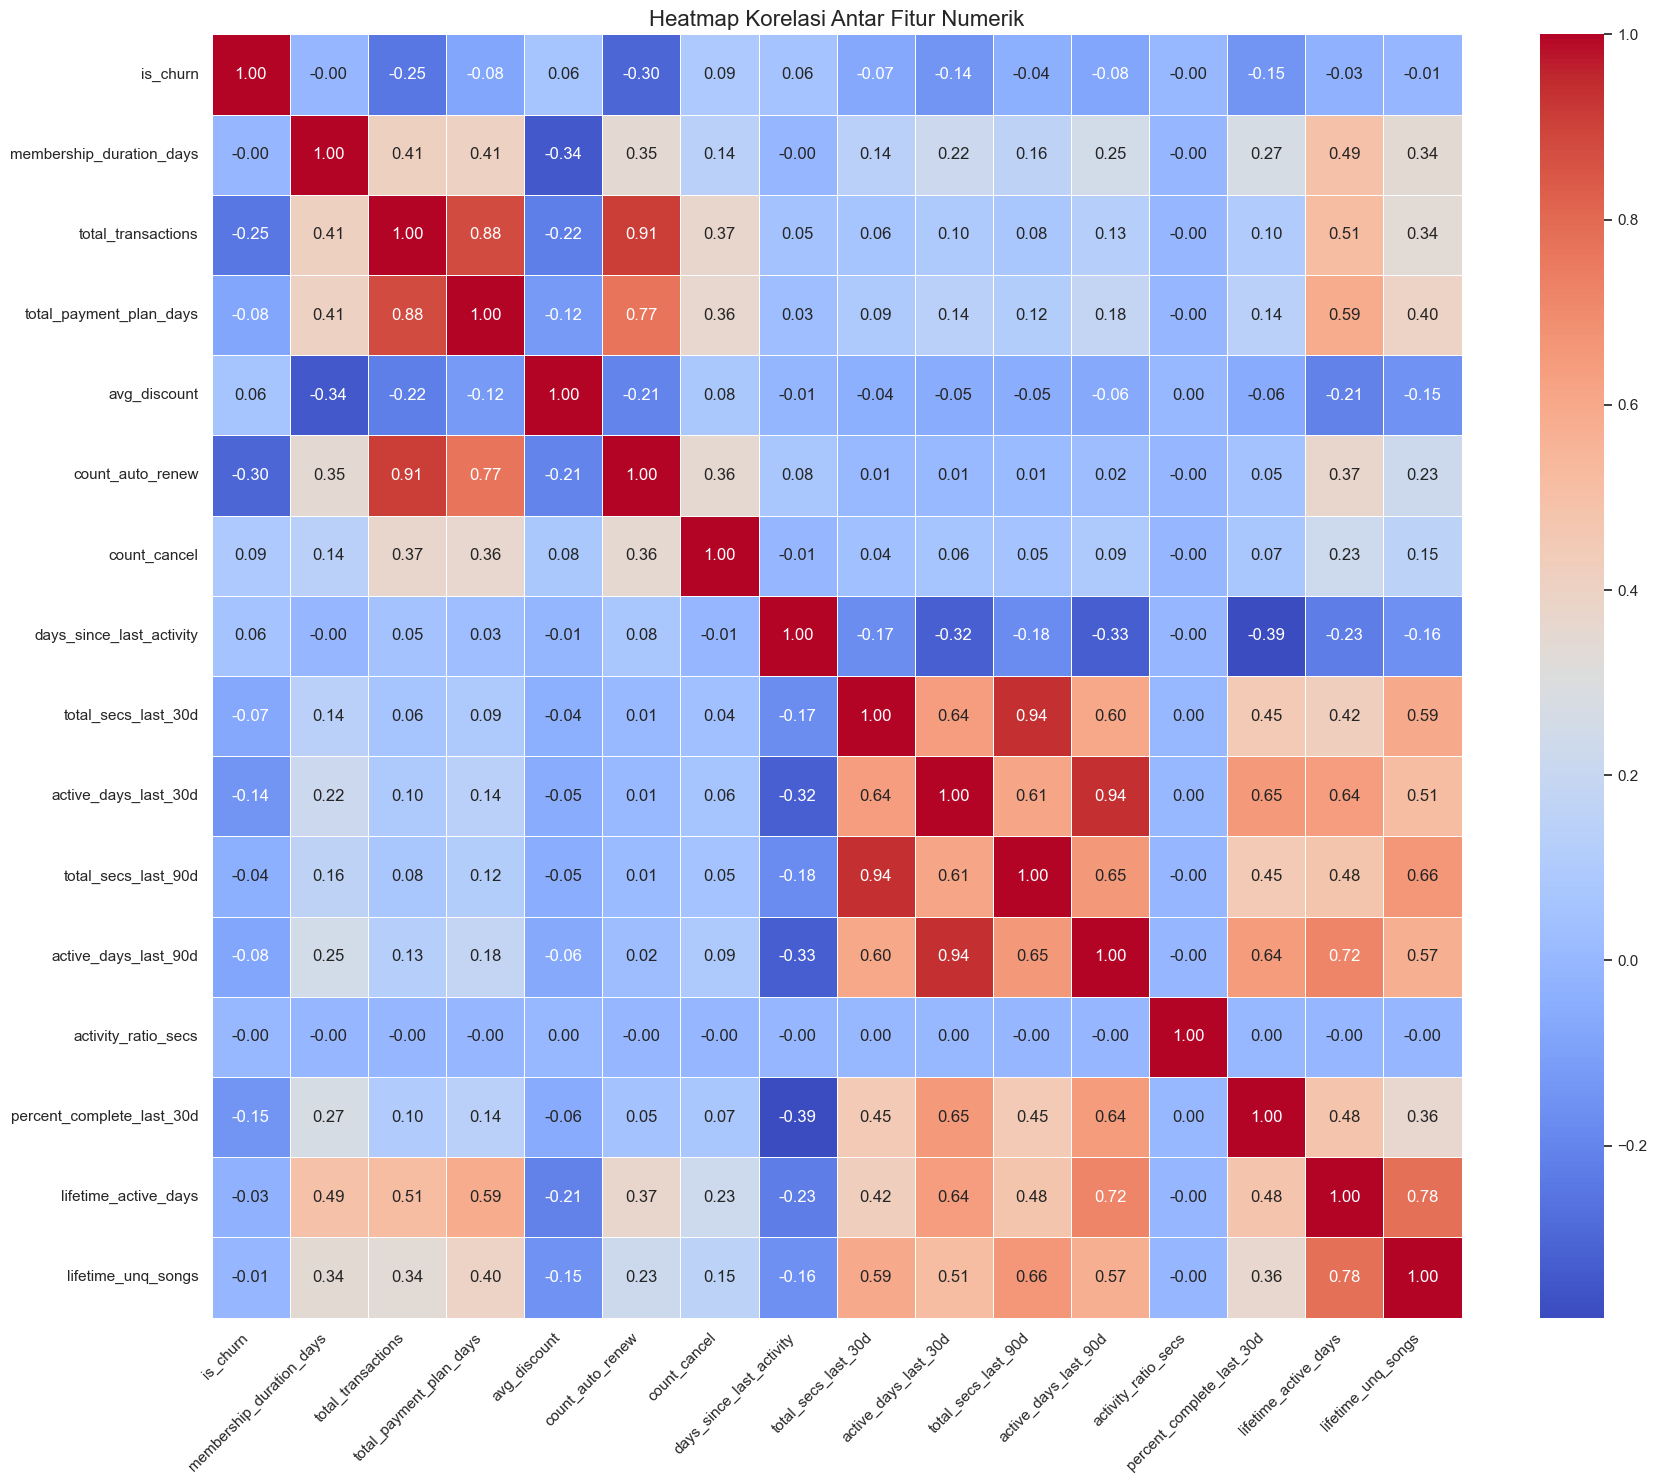

In [ ]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = master_table_spark_3

# 1. Daftar kolom numerik untuk korelasi (berdasarkan skema Anda)
# masukkin juga'is_churn' untuk melihat korelasinya dengan fitur lain,
# tapi hilangin 'msno' dan 'age_group'.
# hilangin juga 'last_transaction_date' dan 'last_expiry_date'
# karena itu adalah tanggal (integer) yang tidak cocok untuk korelasi Pearson.
numerical_cols = [
    "is_churn", # Disertakan untuk melihat korelasi fitur vs target
    "membership_duration_days",
    "total_transactions",
    "total_payment_plan_days",
    "avg_discount",
    "count_auto_renew",
    "count_cancel",
    "days_since_last_activity",
    "total_secs_last_30d",
    "active_days_last_30d",
    "total_secs_last_90d",
    "active_days_last_90d",
    "activity_ratio_secs",
    "percent_complete_last_30d",
    "lifetime_active_days",
    "lifetime_unq_songs"
]

# 2. Buat VectorAssembler
# Korelasi di Spark membutuhkan semua data dalam satu kolom vector
assembler = VectorAssembler(
    inputCols=numerical_cols,
    outputCol="corr_features"
)
df_vector = assembler.transform(df).select("corr_features")

# 3. Hitung Matriks Korelasi Pearson
# Ini mengembalikan DataFrame Spark dengan satu baris berisi matriks
corr_matrix_spark = Correlation.corr(df_vector, "corr_features", "pearson").head()

# 4. Ekstrak matriks dan konversi ke Pandas DataFrame
print("Matriks korelasi berhasil dihitung. Mengonversi ke Pandas...")
corr_matrix_pd = pd.DataFrame(
    corr_matrix_spark[0].toArray(),
    columns=numerical_cols,
    index=numerical_cols
)

# 5. Visualisasikan sebagai Heatmap
print("Membuat heatmap...")
plt.figure(figsize=(18, 15)) # Buat gambar lebih besar agar mudah dibaca
sns.heatmap(
    corr_matrix_pd,
    annot=True,        # Tampilkan angka korelasi
    fmt=".2f",         # Format angka (2 desimal)
    cmap="coolwarm",   # Skema warna (Biru=negatif, Merah=positif)
    linewidths=.5
)
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout() # Memastikan label tidak terpotong

# Simpan gambar
plt.savefig("correlation_heatmap.png")
print("Heatmap berhasil disimpan sebagai 'correlation_heatmap.png'")
plt.show()

**Intepretasi Heatmap**
- Multicollinearity (> 0.85):
-- total_secs_last_90d vs. total_secs_last_30d (Korelasi: 0.94)
-- active_days_last_90d vs. active_days_last_30d (Korelasi: 0.94)
-- total_transactions vs. count_auto_renew (0.91)
-- total_payment_plan_days vs. total_transactions (Korelasi: 0.88)

--> salah satu harus dibuang

- Korelasi dengan is_churn (kekuatan prediktif):
- Korelasi Negatif Terkuat (Biru Tua):

- count_auto_renew (-0.30): semakin tinggi jumlah auto-renew, semakin rendah kemungkinan is_churn.

- total_transactions (-0.25): Semakin banyak transaksi, semakin rendah kemungkinan churn.

- Korelasi Negatif Sedang (Biru):

- percent_complete_last_30d (-0.15): Semakin tinggi persentase lagu selesai, semakin rendah kemungkinan churn.

- active_days_last_30d (-0.14): Semakin banyak hari aktif, semakin rendah kemungkinan churn.

- Korelasi Sangat Lemah / Tidak Ada:

- count_cancel (0.09), days_since_last_activity (0.06), membership_duration_days (-0.00): tidak ada korelasi linear sama sekali.

Catatan!!!:
Ada conflict hasil boxplot dengan heatmap:
- count_cancel: Di boxplot, ini adalah prediktor terkuat kita (churn rate melonjak dari 7.5% ke 15% hanya dengan 1 pembatalan). Tapi di heatmap, korelasinya hanya 0.09 (sangat lemah).

- days_since_last_activity: Di boxplot, ini juga prediktor terkuat (median 0 hari untuk loyal vs 25-30 hari untuk churn). Tapi di heatmap, korelasinya hanya 0.06 (sangat lemah).

Kenapa? 

--> Korelasi Pearson (heatmap) hanya mengukur hubungan linear (garis lurus).

Hubungan antara count_cancel dan is_churn tidak linear. Risikonya melonjak di angka 1, lalu stabil, lalu melonjak lagi di angka 8+. Pearson tidak bisa "melihat" pola lompatan seperti ini, sehingga ia melaporkan korelasi yang lemah.

Buat fitur linear (count_auto_renew, total_transactions valid), fitur non-lienar jd sesat heatmap, PERCAYA BOXPLOT >-<, prediktor sgt kuat keduanya.

## Uji Chi-Square untuk kategorikal (seperti age_group, city, registered_via)

### Fitur vs. Target Label (is_churn)

In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.stat import ChiSquareTest
import pyspark.sql.functions as F

df_test = master_table_spark_3

# Preprocessing untuk Chi-Square
# 1. ubah 'age_group' (string) menjadi angka/indeks
indexer = StringIndexer(
    inputCol="age_group", 
    outputCol="age_group_idx", 
    handleInvalid="keep" # Menangani nilai null/unknown
)
df_indexed = indexer.fit(df_test).transform(df_test)

# 2. Daftar fitur kategorikal (sekarang semua numerik)
# 'city' dan 'registered_via' sudah numerik
indexed_cat_cols = ['age_group_idx', 'city', 'registered_via']

# 3. Gabungkan fitur ke dalam satu vektor
assembler = VectorAssembler(
    inputCols=indexed_cat_cols, 
    outputCol="cat_features_vec"
)
df_vector = assembler.transform(df_indexed)

# 4. Uji Chi-Square
# uji setiap fitur di dalam 'cat_features_vec' terhadap 'is_churn'
print("Menjalankan Uji Chi-Square (Fitur vs. Target 'is_churn')...")
chi_test_result = ChiSquareTest.test(df_vector, "cat_features_vec", "is_churn").head()

print("\nHasil Uji Chi-Square (Fitur vs. Target)")
p_values = chi_test_result.pValues
degrees_of_freedom = chi_test_result.degreesOfFreedom
statistics = chi_test_result.statistics

# 5. Tampilkan hasil
for i, col_name in enumerate(indexed_cat_cols):
    print(f"\nFitur: {col_name} (vs. is_churn)")
    print(f"  p-value     : {p_values[i]}")
    if p_values[i] < 0.05:
        print(f"HASIL: Dependen (p < 0.05). Fitur ini sangat prediktif.")
    else:
        print(f"HASIL: Independen (p > 0.05). Fitur ini mungkin tidak berguna.")

Menjalankan Uji Chi-Square (Fitur vs. Target 'is_churn')...

Hasil Uji Chi-Square (Fitur vs. Target)

Fitur: age_group_idx (vs. is_churn)
  p-value     : 0.0
HASIL: Dependen (p < 0.05). Fitur ini sangat prediktif.

Fitur: city (vs. is_churn)
  p-value     : 0.0
HASIL: Dependen (p < 0.05). Fitur ini sangat prediktif.

Fitur: registered_via (vs. is_churn)
  p-value     : 0.0
HASIL: Dependen (p < 0.05). Fitur ini sangat prediktif.


### Fitur vs. Fitur

In [ ]:
print("\n\n--- Hasil Uji Chi-Square (Fitur vs. Fitur) ---")

# Pasangan 1: age_group_idx vs city
# ubah dulu 'age_group_idx' jadi vektor, dan gunakan 'city' sebagai label
assembler_1 = VectorAssembler(inputCols=['age_group_idx'], outputCol='vec_age')
result_1 = ChiSquareTest.test(
    assembler_1.transform(df_indexed), 'vec_age', 'city'
).head()

print(f"\nTest: age_group vs. city")
print(f"  p-value: {result_1.pValues[0]}")
if result_1.pValues[0] < 0.05:
    print("  ==> HASIL: Dependen. Ada korelasi, pertimbangkan buang salah satu.")
else:
    print("  ==> HASIL: Independen. Bagus, aman digunakan bersamaan.")


# Pasangan 2: age_group_idx vs registered_via
assembler_2 = VectorAssembler(inputCols=['age_group_idx'], outputCol='vec_age')
result_2 = ChiSquareTest.test(
    assembler_2.transform(df_indexed), 'vec_age', 'registered_via'
).head()

print(f"\nTest: age_group vs. registered_via")
print(f"  p-value: {result_2.pValues[0]}")
if result_2.pValues[0] < 0.05:
    print("  ==> HASIL: Dependen. Ada korelasi, pertimbangkan buang salah satu.")
else:
    print("  ==> HASIL: Independen. Bagus, aman digunakan bersamaan.")


# Pasangan 3: city vs registered_via
assembler_3 = VectorAssembler(inputCols=['city'], outputCol='vec_city')
result_3 = ChiSquareTest.test(
    assembler_3.transform(df_indexed), 'vec_city', 'registered_via'
).head()

print(f"\nTest: city vs. registered_via")
print(f"  p-value: {result_3.pValues[0]}")
if result_3.pValues[0] < 0.05:
    print("  ==> HASIL: Dependen. Ada korelasi, pertimbangkan buang salah satu.")
else:
    print("  ==> HASIL: Independen. Bagus, aman digunakan bersamaan.")



--- Hasil Uji Chi-Square (Fitur vs. Fitur) ---

Test: age_group vs. city
  p-value: 0.0
  ==> HASIL: Dependen. Ada korelasi, pertimbangkan buang salah satu.

Test: age_group vs. registered_via
  p-value: 0.0
  ==> HASIL: Dependen. Ada korelasi, pertimbangkan buang salah satu.

Test: city vs. registered_via
  p-value: 0.0
  ==> HASIL: Dependen. Ada korelasi, pertimbangkan buang salah satu.


Memuat data dari data/master_feature_table.parquet...
Mengambil sampel 10% data untuk visualisasi...
Data siap! Jumlah sampel: 44073 baris


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24680\1287938973.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


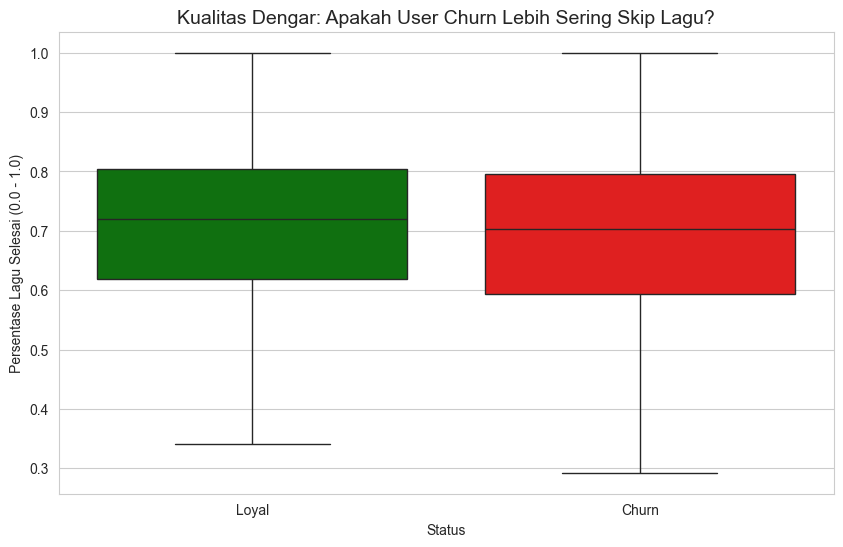

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24680\1287938973.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


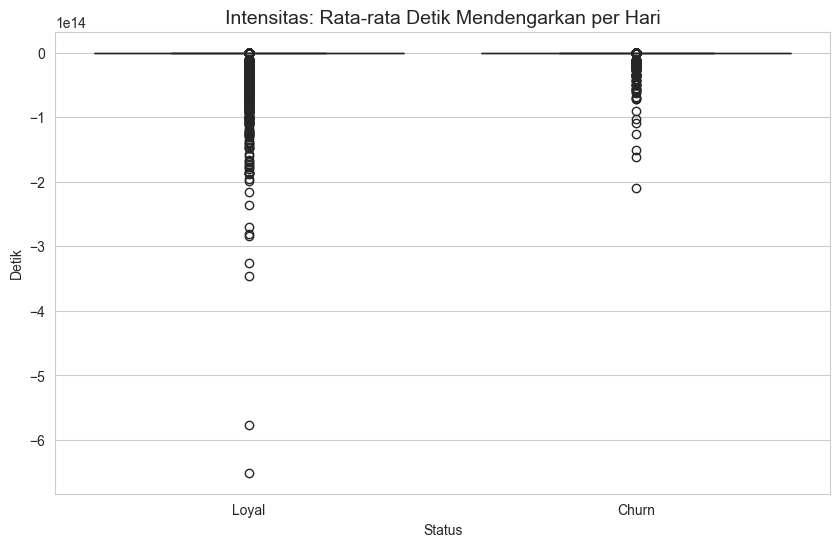

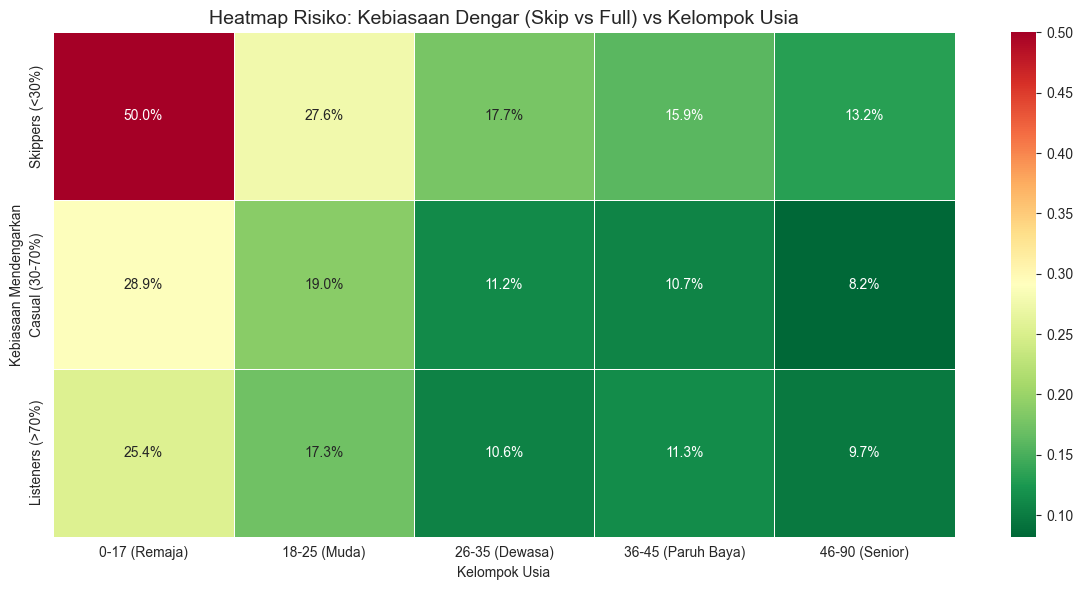

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Inisialisasi Spark
spark = SparkSession.builder \
    .appName("KKBox_Master_Log_EDA") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# 2. Load Master Table
# Sesuai path yang Anda berikan
master_path = "data/master_feature_table.parquet"
print(f"Memuat data dari {master_path}...")
df_master = spark.read.parquet(master_path)

# 3. Pilih Kolom Penting (Fokus ke Logs & Demografi)
# Kita pilih kolom logs yang ada di skema Anda + target & usia
cols_to_analyze = [
    "is_churn", 
    "age_group",
    "percent_songs_completed",  # Kualitas dengar
    "avg_daily_secs",           # Intensitas
    "total_active_days"         # Keaktifan
]

# Filter data:
# - Hapus baris yang nilai logs-nya null (jika ada)
# - Hapus age_group 'Unknown' agar heatmap nanti lebih bersih (opsional)
df_logs_clean = df_master.select(cols_to_analyze) \
    .filter(F.col("age_group") != "Unknown") \
    .na.fill(0) # Isi null di logs dengan 0 (asumsi tidak aktif)

# 4. Sampling & Konversi ke Pandas
# Ambil 10% data agar ringan di memori
print("Mengambil sampel 10% data untuk visualisasi...")
pdf_viz = df_logs_clean.sample(fraction=0.1, seed=42).toPandas()

# Mapping label churn
pdf_viz['Status'] = pdf_viz['is_churn'].map({0: 'Loyal', 1: 'Churn'})

print(f"Data siap! Jumlah sampel: {len(pdf_viz)} baris")

# ==========================================
# BAGIAN VISUALISASI
# ==========================================
sns.set_style("whitegrid")

# --- 1. BOXPLOT: KUALITAS DENGAR (SKIP vs FULL) ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=pdf_viz, 
    x='Status', 
    y='percent_songs_completed', 
    palette={'Loyal': 'green', 'Churn': 'red'},
    showfliers=False
)
plt.title('Kualitas Dengar: Apakah User Churn Lebih Sering Skip Lagu?', fontsize=14)
plt.ylabel('Persentase Lagu Selesai (0.0 - 1.0)')
plt.show()

# --- 2. BOXPLOT: INTENSITAS (Detik per Hari) ---
plt.figure(figsize=(10, 6))
# Batasi y-axis jika ada outlier ekstrem (misal > 24 jam/86400 detik)
sns.boxplot(
    data=pdf_viz[pdf_viz['avg_daily_secs'] < 50000], 
    x='Status', 
    y='avg_daily_secs', 
    palette={'Loyal': 'green', 'Churn': 'red'}
)
plt.title('Intensitas: Rata-rata Detik Mendengarkan per Hari', fontsize=14)
plt.ylabel('Detik')
plt.show()

# --- 3. HEATMAP: KEBIASAAN DENGAR vs USIA ---
# Ini untuk melihat apakah "Remaja yang Suka Skip" benar-benar kelompok paling bahaya.

# A. Buat Kategori Kebiasaan (Binning) di Pandas
def get_habit(rate):
    if rate < 0.3: return "Skippers (<30%)"   # Sering skip
    elif rate > 0.7: return "Listeners (>70%)" # Dengar full
    else: return "Casual (30-70%)"            # Biasa saja

pdf_viz['habit'] = pdf_viz['percent_songs_completed'].apply(get_habit)

# B. Hitung Rata-rata Churn
heatmap_data = pdf_viz.pivot_table(
    index='habit', 
    columns='age_group', 
    values='is_churn', 
    aggfunc='mean'
)

# C. Urutkan Index/Columns
age_order = sorted(pdf_viz['age_group'].unique())
habit_order = ["Skippers (<30%)", "Casual (30-70%)", "Listeners (>70%)"]
heatmap_data = heatmap_data.reindex(index=habit_order, columns=age_order)

# D. Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".1%", 
    cmap="RdYlGn_r", 
    linewidths=.5
)
plt.title('Heatmap Risiko: Kebiasaan Dengar (Skip vs Full) vs Kelompok Usia', fontsize=14)
plt.ylabel('Kebiasaan Mendengarkan')
plt.xlabel('Kelompok Usia')
plt.tight_layout()
plt.show()

Memulai Visualisasi User Logs per Kelompok Usia...
Memuat data dari data/master_feature_table.parquet...
Mengambil sampel data dan konversi ke Pandas...
Data siap! Total sampel: 88344 baris.


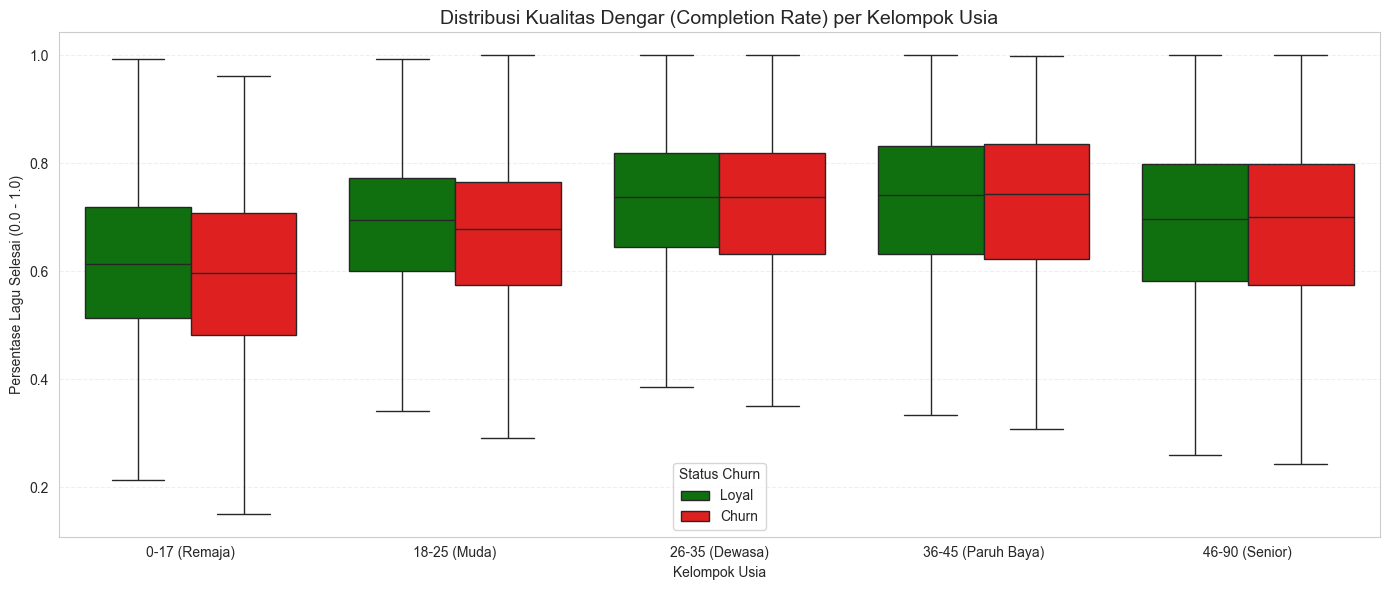

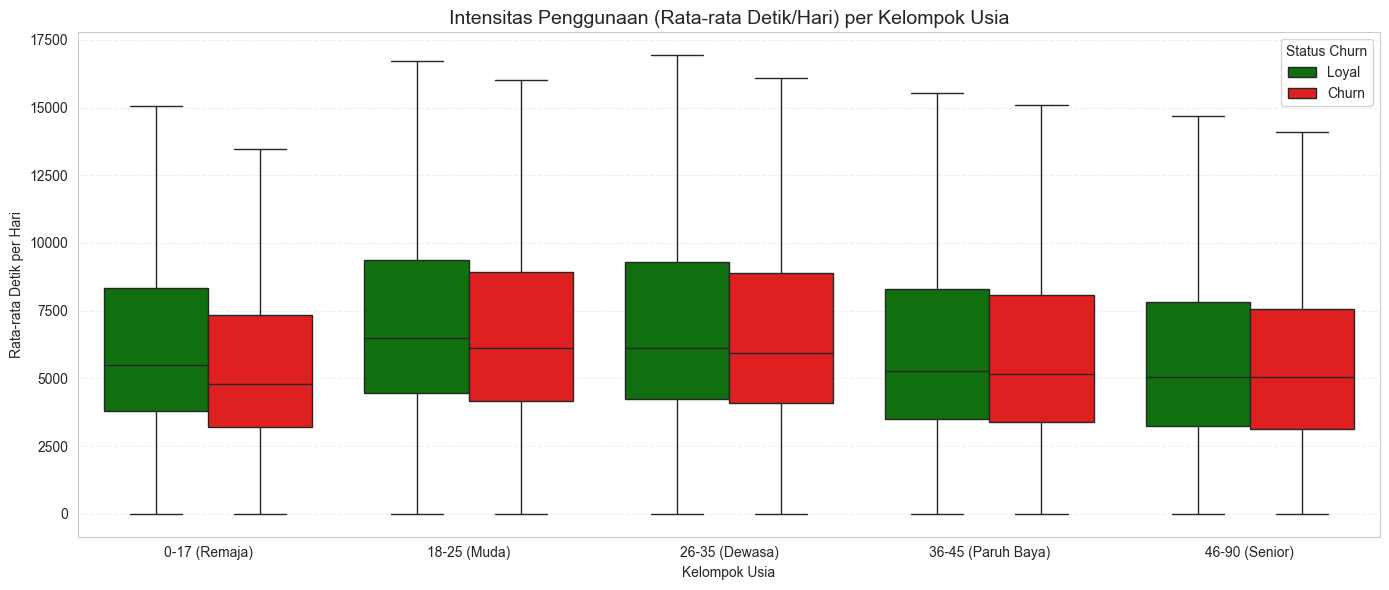

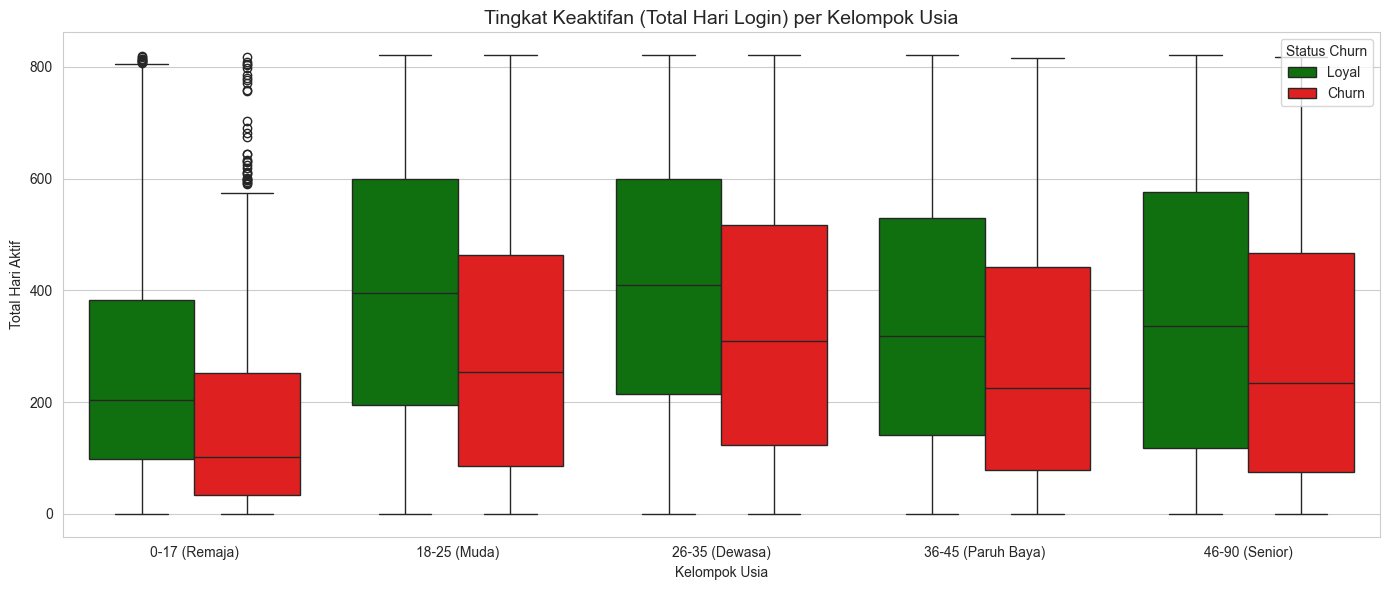

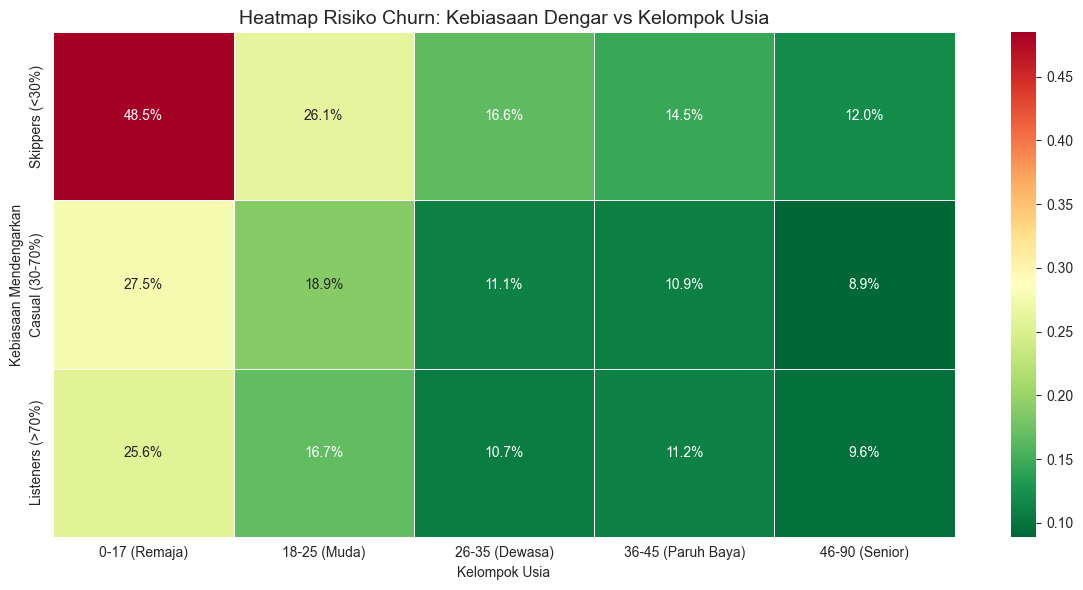

Analisis User Logs selesai.


In [ ]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# ANALISIS MENDALAM: USER LOGS vs KELOMPOK USIA
# ==========================================
print("Memulai Visualisasi User Logs per Kelompok Usia...")

# 1. LOAD DATA
# Pastikan path ini benar
master_path = "data/master_feature_table.parquet"
print(f"Memuat data dari {master_path}...")
df_master = spark.read.parquet(master_path)

# 2. SELEKSI KOLOM (Sesuai Schema Master Table Anda)
# Kita pilih fitur logs yang paling relevan + demografi
cols_to_use = [
    "msno", "is_churn", "age_group",
    "percent_songs_completed",  # Kualitas (Suka skip atau tidak)
    "avg_daily_secs",           # Intensitas (Berapa lama dengar per hari)
    "total_active_days",        # Loyalitas (Berapa sering login)
    "avg_num_25"                # Sinyal Skip (Lagu diputar < 25%)
]

# Filter:
# - Hapus age_group 'Unknown' agar grafik fokus pada perbandingan generasi
# - Isi null dengan 0 (asumsi user tidak aktif)
df_eda_age = df_master.select(cols_to_use) \
    .filter(F.col("age_group") != "Unknown") \
    .na.fill(0)

# 3. KONVERSI KE PANDAS
# Kita ambil sampel yang cukup besar (misal 20%) agar representatif tapi tidak OOM
print("Mengambil sampel data dan konversi ke Pandas...")
pdf_age_logs = df_eda_age.sample(fraction=0.2, seed=42).toPandas()

# Mapping Label untuk Legenda Grafik
pdf_age_logs['Status'] = pdf_age_logs['is_churn'].map({0: 'Loyal', 1: 'Churn'})

# Urutkan Kelompok Usia
age_order = sorted(pdf_age_logs['age_group'].unique())

print(f"Data siap! Total sampel: {len(pdf_age_logs)} baris.")

# ==========================================
# VISUALISASI 1: KUALITAS DENGAR (SKIP) VS USIA
# "Apakah Remaja lebih sering skip lagu dibanding Senior?"
# ==========================================
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=pdf_age_logs,
    x='age_group',
    y='percent_songs_completed',
    hue='Status',
    order=age_order,
    palette={'Loyal': 'green', 'Churn': 'red'},
    showfliers=False # Sembunyikan outlier agar pola utama terlihat
)

plt.title('Distribusi Kualitas Dengar (Completion Rate) per Kelompok Usia', fontsize=14)
plt.ylabel('Persentase Lagu Selesai (0.0 - 1.0)')
plt.xlabel('Kelompok Usia')
plt.legend(title='Status Churn')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALISASI 2: INTENSITAS (DURASI) VS USIA
# "Apakah Remaja mendengarkan lebih lama/banyak?"
# ==========================================
plt.figure(figsize=(14, 6))

# Batasi outlier ekstrem (misal > 50.000 detik/hari) agar grafik terbaca
plot_data_secs = pdf_age_logs[pdf_age_logs['avg_daily_secs'] < 50000]

sns.boxplot(
    data=plot_data_secs,
    x='age_group',
    y='avg_daily_secs',
    hue='Status',
    order=age_order,
    palette={'Loyal': 'green', 'Churn': 'red'},
    showfliers=False
)

plt.title('Intensitas Penggunaan (Rata-rata Detik/Hari) per Kelompok Usia', fontsize=14)
plt.ylabel('Rata-rata Detik per Hari')
plt.xlabel('Kelompok Usia')
plt.legend(title='Status Churn')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALISASI 3: KEAKTIFAN (FREKUENSI) VS USIA
# "Siapa yang paling jarang login?"
# ==========================================
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=pdf_age_logs,
    x='age_group',
    y='total_active_days',
    hue='Status',
    order=age_order,
    palette={'Loyal': 'green', 'Churn': 'red'}
)

plt.title('Tingkat Keaktifan (Total Hari Login) per Kelompok Usia', fontsize=14)
plt.ylabel('Total Hari Aktif')
plt.xlabel('Kelompok Usia')
plt.legend(title='Status Churn')
plt.tight_layout()
plt.show()

# ==========================================
# VISUALISASI 4: HEATMAP RISIKO (KEBIASAAN x USIA)
# "Apakah 'Suka Skip' lebih fatal bagi Remaja?"
# ==========================================

# A. Buat Kategori Kebiasaan (Binning)
def get_habit(rate):
    if rate < 0.3: return "Skippers (<30%)"   # Sering skip/Ganti lagu
    elif rate > 0.7: return "Listeners (>70%)" # Dengar sampai habis
    else: return "Casual (30-70%)"            # Campuran

pdf_age_logs['habit'] = pdf_age_logs['percent_songs_completed'].apply(get_habit)

# B. Pivot Table untuk Churn Rate
heatmap_data = pdf_age_logs.pivot_table(
    index='habit', 
    columns='age_group', 
    values='is_churn', 
    aggfunc='mean'
)

# C. Reorder agar urutannya logis
habit_order = ["Skippers (<30%)", "Casual (30-70%)", "Listeners (>70%)"]
heatmap_data = heatmap_data.reindex(index=habit_order, columns=age_order)

# D. Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".1%", 
    cmap="RdYlGn_r", # Merah = Risiko Churn Tinggi
    linewidths=.5
)
plt.title('Heatmap Risiko Churn: Kebiasaan Dengar vs Kelompok Usia', fontsize=14)
plt.ylabel('Kebiasaan Mendengarkan')
plt.xlabel('Kelompok Usia')
plt.tight_layout()
plt.show()

print("Analisis User Logs selesai.")

Memulai Visualisasi User Logs (Fitur Baru) per Kelompok Usia...
Memuat data dari data/master_feature_table_3.parquet...
Mengambil sampel data...
Data siap! Total sampel: 88349 baris.


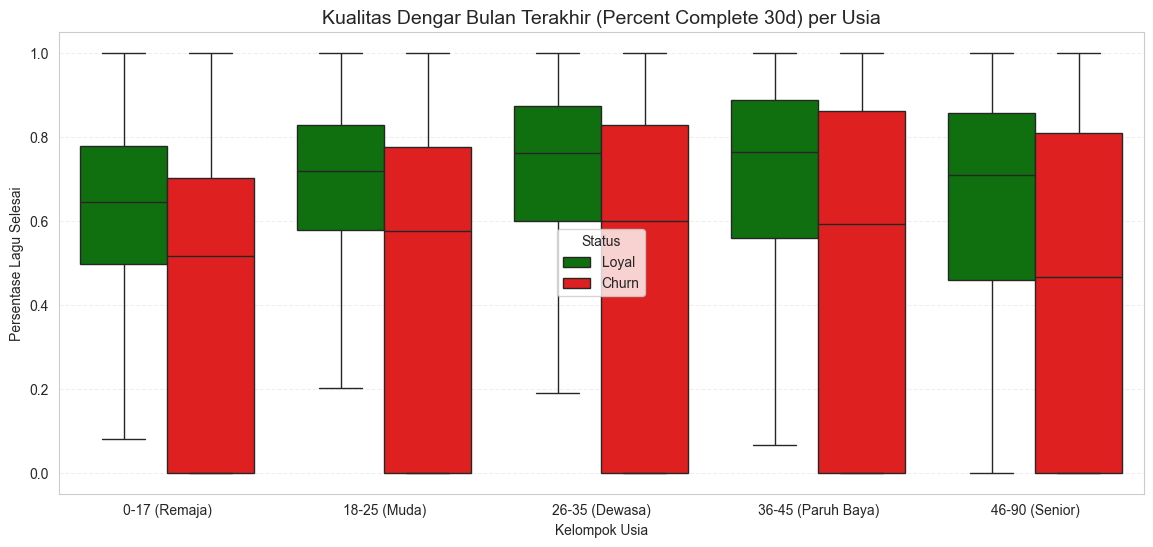

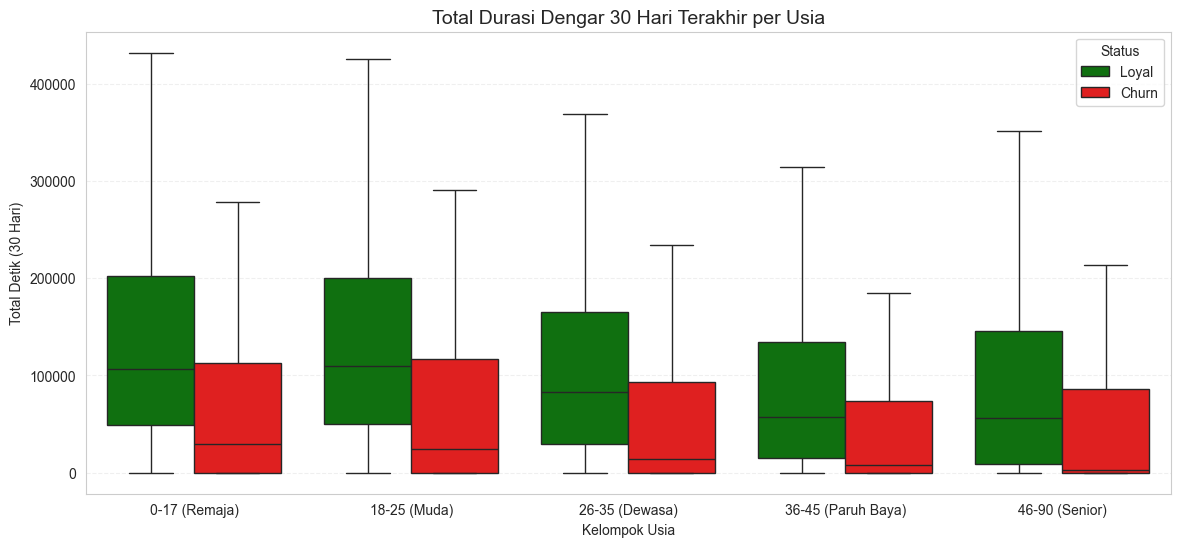

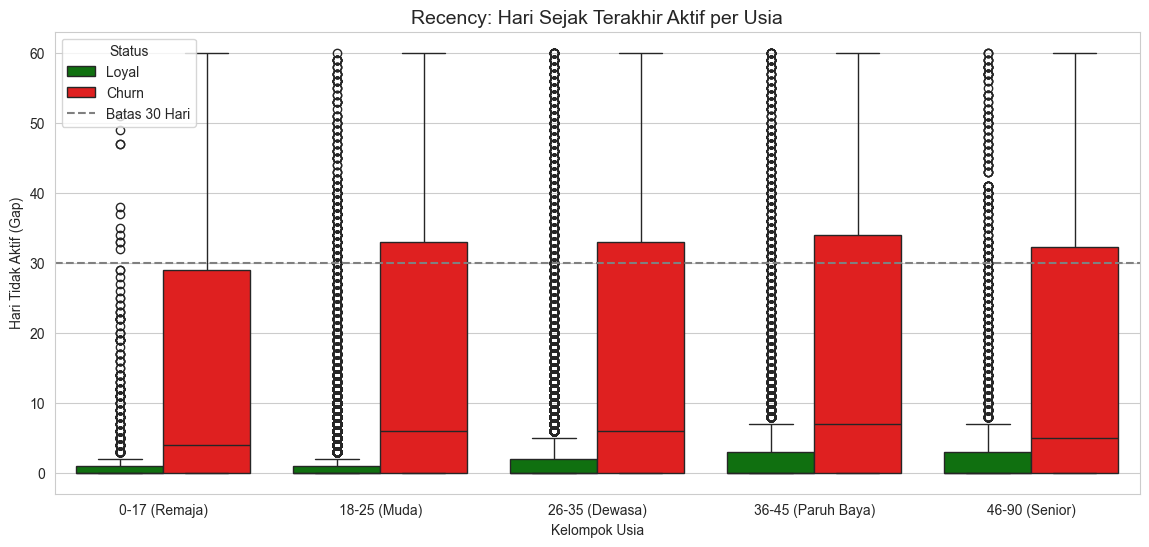

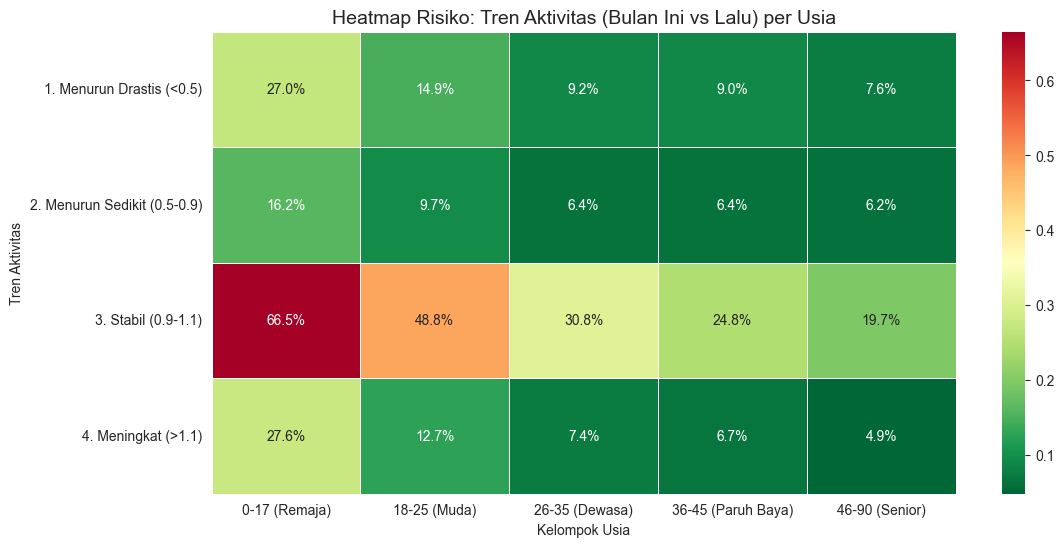

Analisis Selesai.


In [ ]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# ANALISIS USER LOGS (RECENCY & TREND) vs USIA
# ==========================================
print("Memulai Visualisasi User Logs (Fitur Baru) per Kelompok Usia...")

# 1. LOAD DATA
# Pastikan file master ini sudah dibuat dengan fungsi agregasi BARU
master_path = "data/master_feature_table_3.parquet"
print(f"Memuat data dari {master_path}...")
df_master = spark.read.parquet(master_path)

# 2. SELEKSI KOLOM BARU (Sesuai Agregasi Recency & Trend)
# Perhatikan perubahan nama kolom di sini:
cols_to_use = [
    "msno", "is_churn", "age_group",
    
    # Fitur Baru:
    "percent_complete_last_30d",  # Kualitas (Ganti percent_songs_completed)
    "total_secs_last_30d",        # Intensitas (Ganti avg_daily_secs)
    "active_days_last_30d",       # Keaktifan (Ganti total_active_days)
    "days_since_last_activity",   # Recency (Fitur paling penting!)
    "activity_ratio_secs"         # Trend (Naik/Turun)
]

# Cek apakah kolom ada (untuk debugging)
existing_cols = df_master.columns
for c in cols_to_use:
    if c not in existing_cols:
        print(f"⚠️ PERINGATAN: Kolom '{c}' tidak ditemukan di tabel master!")

# Filter data
df_eda_new = df_master.select(cols_to_use) \
    .filter(F.col("age_group") != "Unknown") \
    .na.fill(0)

# 3. KONVERSI KE PANDAS
print("Mengambil sampel data...")
pdf_viz = df_eda_new.sample(fraction=0.2, seed=42).toPandas()

# Mapping Label
pdf_viz['Status'] = pdf_viz['is_churn'].map({0: 'Loyal', 1: 'Churn'})
age_order = sorted(pdf_viz['age_group'].unique())

print(f"Data siap! Total sampel: {len(pdf_viz)} baris.")

# ==========================================
# VISUALISASI 1: KUALITAS DENGAR 30 HARI TERAKHIR
# ==========================================
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=pdf_viz,
    x='age_group',
    y='percent_complete_last_30d', # Kolom Baru
    hue='Status',
    order=age_order,
    palette={'Loyal': 'green', 'Churn': 'red'},
    showfliers=False
)
plt.title('Kualitas Dengar Bulan Terakhir (Percent Complete 30d) per Usia', fontsize=14)
plt.ylabel('Persentase Lagu Selesai')
plt.xlabel('Kelompok Usia')
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# ==========================================
# VISUALISASI 2: INTENSITAS (TOTAL SECS 30D)
# ==========================================
plt.figure(figsize=(14, 6))
# Batasi outlier ekstrem (misal > 500.000 detik/bulan)
plot_secs = pdf_viz[pdf_viz['total_secs_last_30d'] < 500000]

sns.boxplot(
    data=plot_secs,
    x='age_group',
    y='total_secs_last_30d', # Kolom Baru
    hue='Status',
    order=age_order,
    palette={'Loyal': 'green', 'Churn': 'red'},
    showfliers=False
)
plt.title('Total Durasi Dengar 30 Hari Terakhir per Usia', fontsize=14)
plt.ylabel('Total Detik (30 Hari)')
plt.xlabel('Kelompok Usia')
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# ==========================================
# VISUALISASI 3: RECENCY (HARI SEJAK TERAKHIR AKTIF)
# "Siapa yang paling cepat menghilang?"
# ==========================================
plt.figure(figsize=(14, 6))
# Batasi max 60 hari agar grafik fokus
plot_recency = pdf_viz[pdf_viz['days_since_last_activity'] <= 60]

sns.boxplot(
    data=plot_recency,
    x='age_group',
    y='days_since_last_activity', # Kolom Baru
    hue='Status',
    order=age_order,
    palette={'Loyal': 'green', 'Churn': 'red'}
)
plt.title('Recency: Hari Sejak Terakhir Aktif per Usia', fontsize=14)
plt.ylabel('Hari Tidak Aktif (Gap)')
plt.xlabel('Kelompok Usia')
plt.axhline(y=30, color='gray', linestyle='--', label='Batas 30 Hari')
plt.legend(title='Status')
plt.show()

# ==========================================
# VISUALISASI 4: HEATMAP TREN AKTIVITAS
# "Apakah penurunan aktivitas (Trend < 1) berbahaya?"
# ==========================================

# A. Buat Kategori Trend (Binning)
def get_trend(ratio):
    if ratio < 0.5: return "1. Menurun Drastis (<0.5)"
    elif ratio < 0.9: return "2. Menurun Sedikit (0.5-0.9)"
    elif ratio <= 1.1: return "3. Stabil (0.9-1.1)"
    else: return "4. Meningkat (>1.1)"

pdf_viz['trend_group'] = pdf_viz['activity_ratio_secs'].apply(get_trend)

# B. Pivot Table
heatmap_data = pdf_viz.pivot_table(
    index='trend_group', 
    columns='age_group', 
    values='is_churn', 
    aggfunc='mean'
)

# C. Reorder
trend_order = ["1. Menurun Drastis (<0.5)", "2. Menurun Sedikit (0.5-0.9)", "3. Stabil (0.9-1.1)", "4. Meningkat (>1.1)"]
heatmap_data = heatmap_data.reindex(index=trend_order, columns=age_order)

# D. Plot
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".1%", 
    cmap="RdYlGn_r", 
    linewidths=.5
)
plt.title('Heatmap Risiko: Tren Aktivitas (Bulan Ini vs Lalu) per Usia', fontsize=14)
plt.ylabel('Tren Aktivitas')
plt.xlabel('Kelompok Usia')
plt.show()

print("Analisis Selesai.")

=== Memulai Visualisasi User Logs (FULL DATA) ===
Memuat data dari data/master_feature_table_3.parquet...
Sedang convert Spark DataFrame ke Pandas (Full Data)...
Mohon tunggu, proses ini bergantung pada kecepatan memori driver Anda...
Data berhasil dimuat! Total baris: 440,197


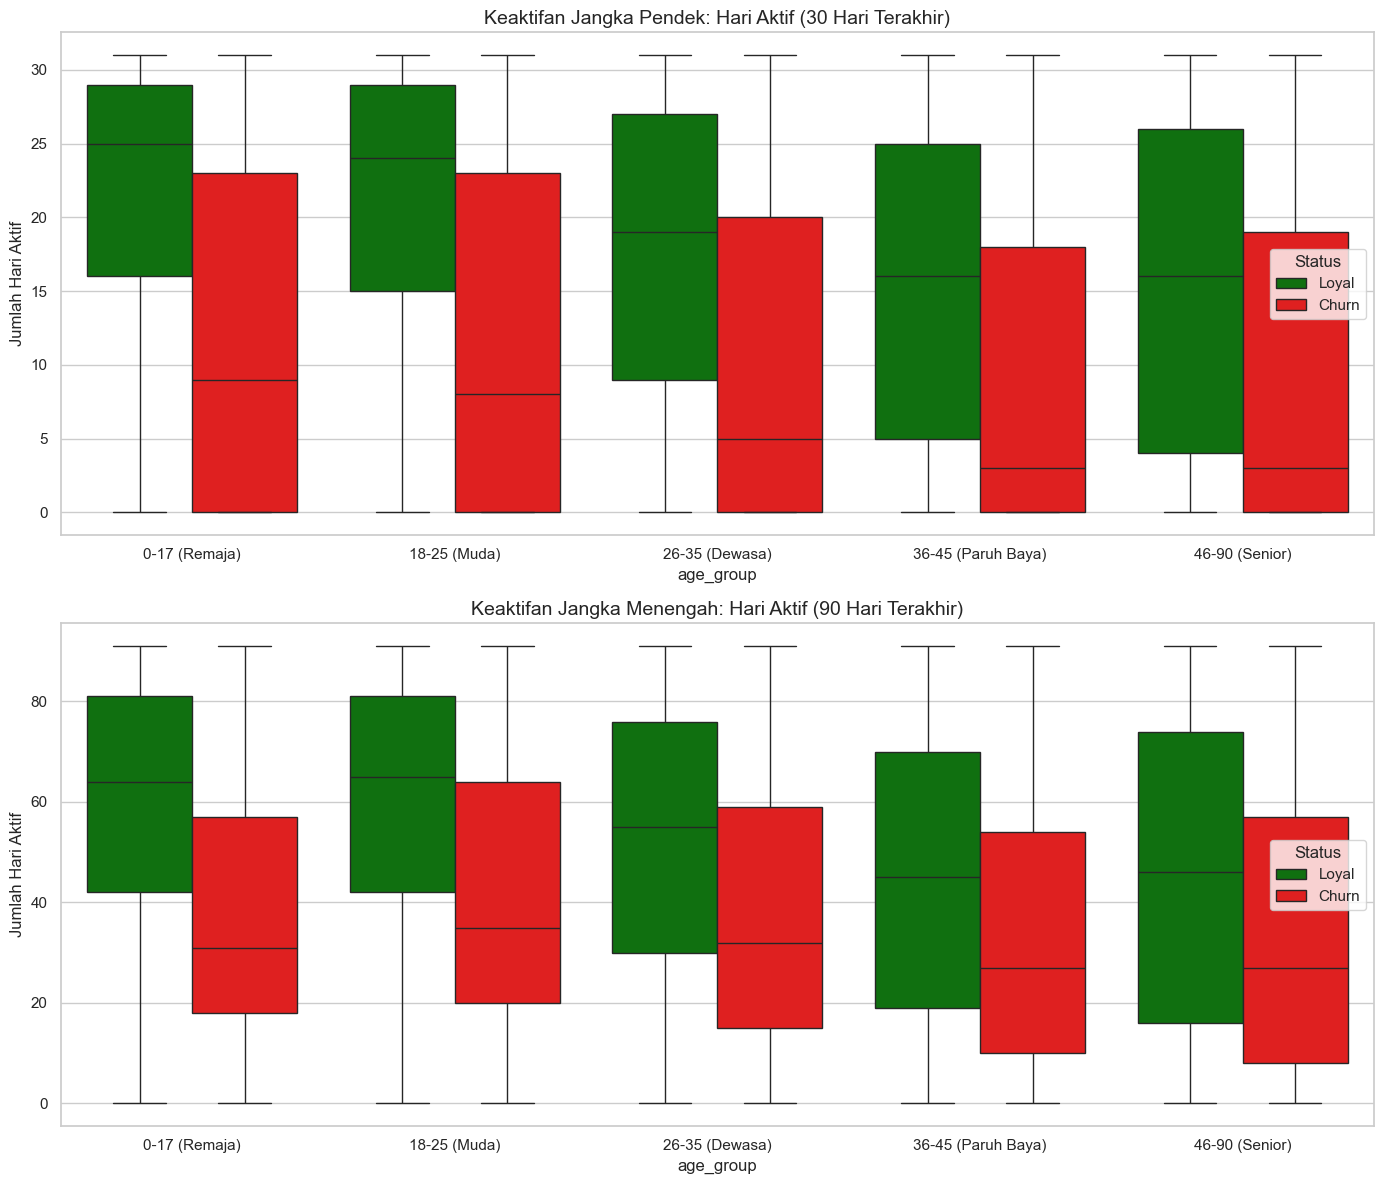

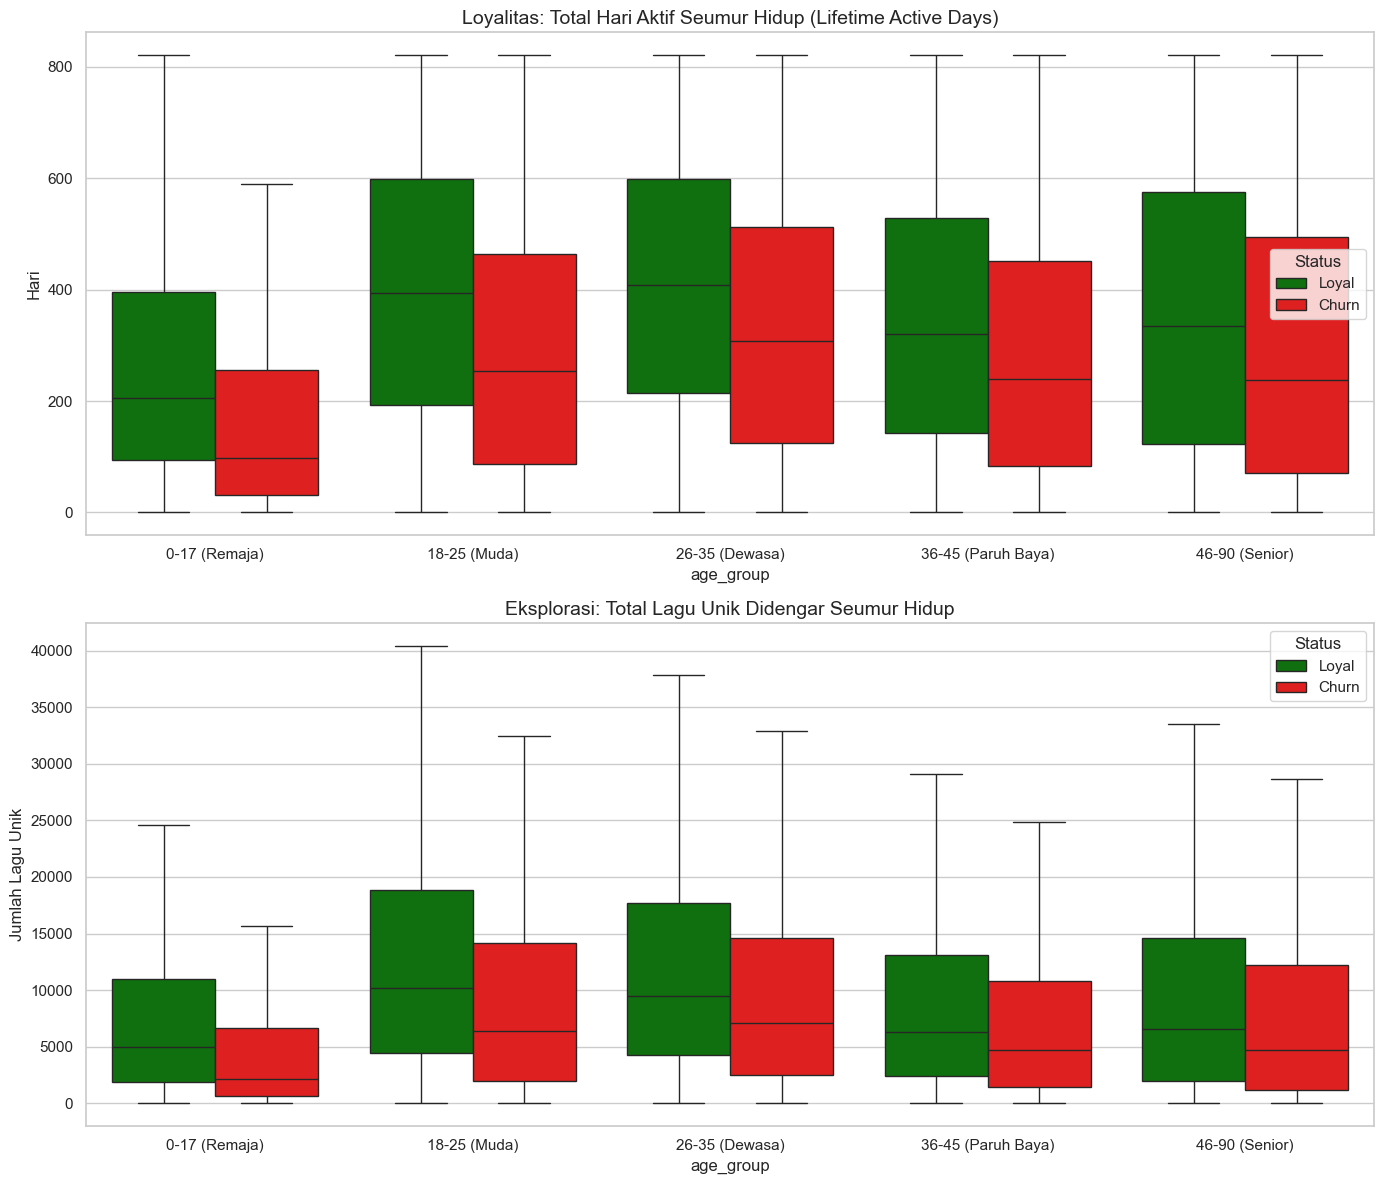

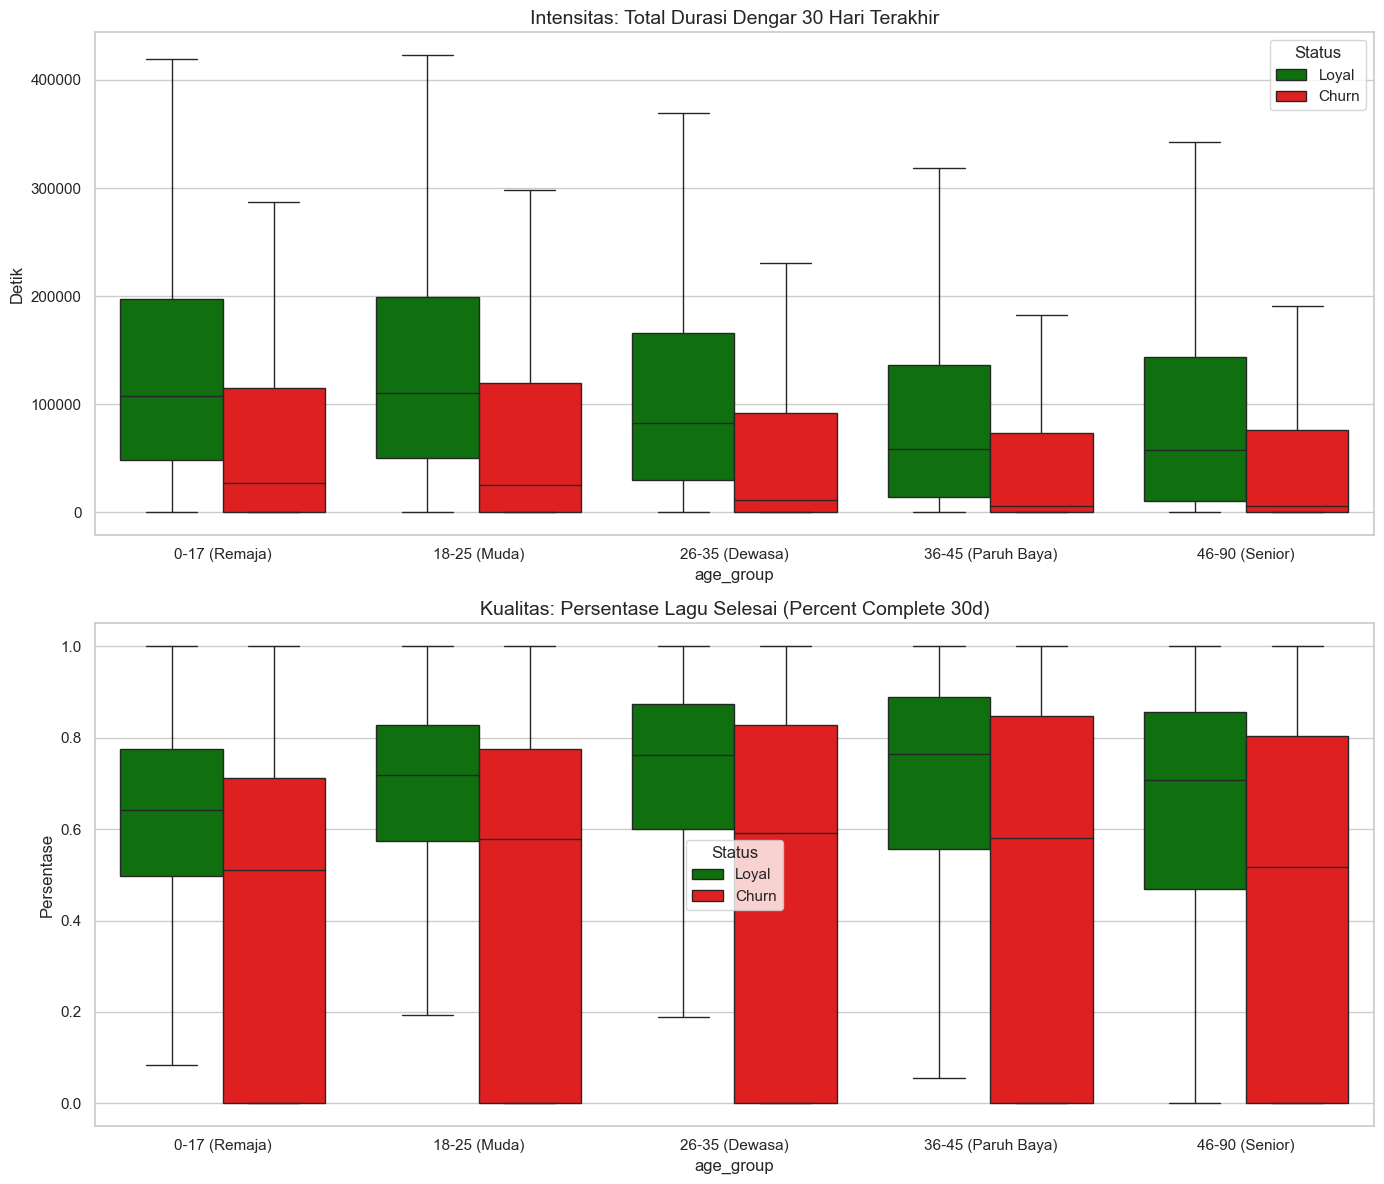

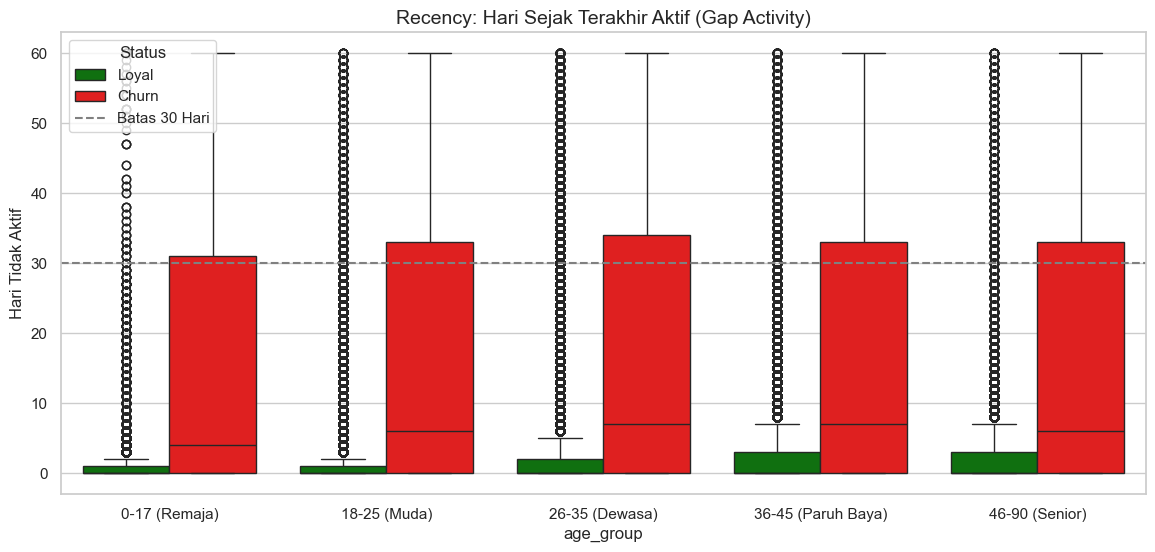

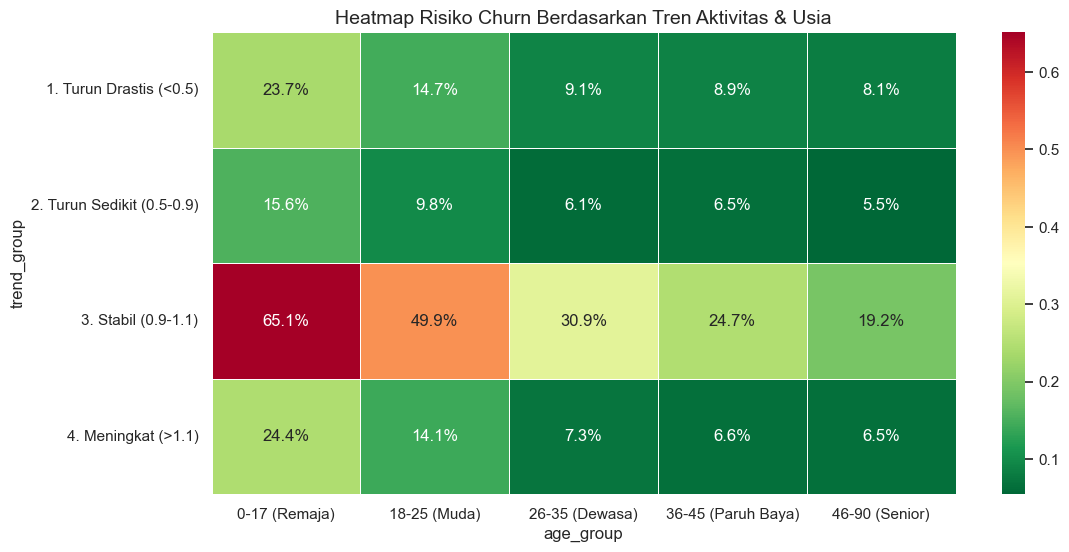

Menghitung Korelasi Pearson pada Full Data...


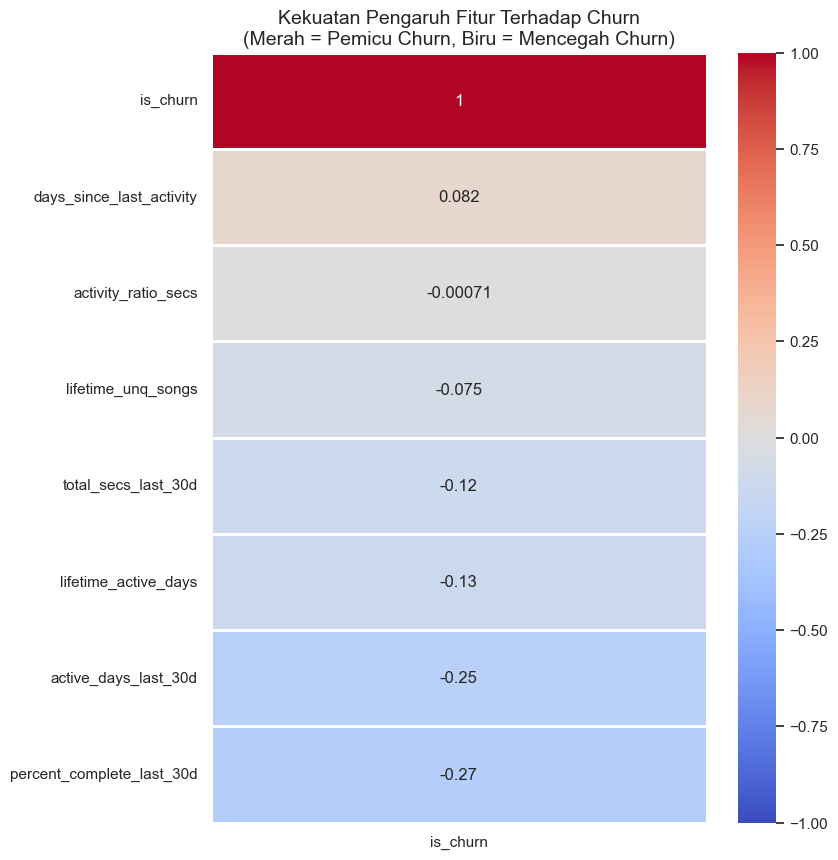

Analisis Selesai.


In [12]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# ANALISIS USER LOGS LENGKAP (FULL DATA)
# ==========================================
print("=== Memulai Visualisasi User Logs (FULL DATA) ===")

# 1. LOAD DATA
master_path = "data/master_feature_table_3.parquet"
print(f"Memuat data dari {master_path}...")
df_master = spark.read.parquet(master_path)

# 2. SELEKSI SEMUA KOLOM USER LOGS
cols_to_use = [
    "msno", "is_churn", "age_group",
    
    # A. Short Term (30 Hari)
    "percent_complete_last_30d",  # Kualitas
    "total_secs_last_30d",        # Intensitas
    "active_days_last_30d",       # Keaktifan
    "days_since_last_activity",   # Recency
    
    # B. Medium Term (90 Hari) - FITUR BARU
    "total_secs_last_90d",        
    "active_days_last_90d",       
    
    # C. Lifetime (Long Term) - FITUR BARU
    "lifetime_active_days",       # Seberapa 'senior' user ini?
    "lifetime_unq_songs",         # Seberapa luas eksplorasi lagunya?
    
    # D. Trend
    "activity_ratio_secs"         # Trend Aktivitas
]

# Filter data (Hapus Unknown Age & Fill Null)
df_eda_full = df_master.select(cols_to_use) \
    .filter(F.col("age_group") != "Unknown") \
    .na.fill(0)

# 3. KONVERSI KE PANDAS (FULL DATA)
print("Sedang convert Spark DataFrame ke Pandas (Full Data)...")
print("Mohon tunggu, proses ini bergantung pada kecepatan memori driver Anda...")

# --- TANPA SAMPLING ---
pdf_viz = df_eda_full.toPandas()

# Mapping Label & Sorting
pdf_viz['Status'] = pdf_viz['is_churn'].map({0: 'Loyal', 1: 'Churn'})
age_order = sorted(pdf_viz['age_group'].unique())

print(f"Data berhasil dimuat! Total baris: {len(pdf_viz):,}")

# ==========================================
# VISUALISASI 1: KEAKTIFAN (30 Hari vs 90 Hari)
# "Apakah user churn memang jarang aktif?"
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Active Days 30d
sns.boxplot(
    data=pdf_viz, x='age_group', y='active_days_last_30d',
    hue='Status', order=age_order, palette={'Loyal': 'green', 'Churn': 'red'},
    showfliers=False, ax=axes[0]
)
axes[0].set_title('Keaktifan Jangka Pendek: Hari Aktif (30 Hari Terakhir)', fontsize=14)
axes[0].set_ylabel('Jumlah Hari Aktif')

# Plot 2: Active Days 90d
sns.boxplot(
    data=pdf_viz, x='age_group', y='active_days_last_90d',
    hue='Status', order=age_order, palette={'Loyal': 'green', 'Churn': 'red'},
    showfliers=False, ax=axes[1]
)
axes[1].set_title('Keaktifan Jangka Menengah: Hari Aktif (90 Hari Terakhir)', fontsize=14)
axes[1].set_ylabel('Jumlah Hari Aktif')

plt.tight_layout()
plt.show()

# ==========================================
# VISUALISASI 2: LIFETIME STATS (Maturity & Exploration)
# "Apakah user baru lebih rentan churn?"
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Lifetime Active Days (Tanpa outlier ekstrem > 5 tahun agar grafik terbaca)
plot_life = pdf_viz[pdf_viz['lifetime_active_days'] < 2000] 

sns.boxplot(
    data=plot_life, x='age_group', y='lifetime_active_days',
    hue='Status', order=age_order, palette={'Loyal': 'green', 'Churn': 'red'},
    showfliers=False, ax=axes[0]
)
axes[0].set_title('Loyalitas: Total Hari Aktif Seumur Hidup (Lifetime Active Days)', fontsize=14)
axes[0].set_ylabel('Hari')

# Plot 2: Lifetime Unique Songs
sns.boxplot(
    data=pdf_viz, x='age_group', y='lifetime_unq_songs',
    hue='Status', order=age_order, palette={'Loyal': 'green', 'Churn': 'red'},
    showfliers=False, ax=axes[1]
)
axes[1].set_title('Eksplorasi: Total Lagu Unik Didengar Seumur Hidup', fontsize=14)
axes[1].set_ylabel('Jumlah Lagu Unik')

plt.tight_layout()
plt.show()

# ==========================================
# VISUALISASI 3: INTENSITAS & KUALITAS (30 Hari)
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Total Seconds (Batasi outlier 500k detik)
plot_secs = pdf_viz[pdf_viz['total_secs_last_30d'] < 500000]
sns.boxplot(
    data=plot_secs, x='age_group', y='total_secs_last_30d',
    hue='Status', order=age_order, palette={'Loyal': 'green', 'Churn': 'red'},
    showfliers=False, ax=axes[0]
)
axes[0].set_title('Intensitas: Total Durasi Dengar 30 Hari Terakhir', fontsize=14)
axes[0].set_ylabel('Detik')

# Plot 2: Percent Complete
sns.boxplot(
    data=pdf_viz, x='age_group', y='percent_complete_last_30d',
    hue='Status', order=age_order, palette={'Loyal': 'green', 'Churn': 'red'},
    showfliers=False, ax=axes[1]
)
axes[1].set_title('Kualitas: Persentase Lagu Selesai (Percent Complete 30d)', fontsize=14)
axes[1].set_ylabel('Persentase')

plt.tight_layout()
plt.show()

# ==========================================
# VISUALISASI 4: RECENCY (Kapan Terakhir Aktif?)
# ==========================================
plt.figure(figsize=(14, 6))
# Fokus ke gap 0-60 hari agar terlihat jelas bedanya
plot_recency = pdf_viz[pdf_viz['days_since_last_activity'] <= 60]

sns.boxplot(
    data=plot_recency, x='age_group', y='days_since_last_activity',
    hue='Status', order=age_order, palette={'Loyal': 'green', 'Churn': 'red'}
)
plt.axhline(y=30, color='gray', linestyle='--', label='Batas 30 Hari')
plt.title('Recency: Hari Sejak Terakhir Aktif (Gap Activity)', fontsize=14)
plt.ylabel('Hari Tidak Aktif')
plt.legend(title='Status')
plt.show()

# ==========================================
# VISUALISASI 5: TREND GROUP HEATMAP
# ==========================================
# A. Buat Kategori Trend
def get_trend(ratio):
    if ratio < 0.5: return "1. Turun Drastis (<0.5)"
    elif ratio < 0.9: return "2. Turun Sedikit (0.5-0.9)"
    elif ratio <= 1.1: return "3. Stabil (0.9-1.1)"
    else: return "4. Meningkat (>1.1)"

pdf_viz['trend_group'] = pdf_viz['activity_ratio_secs'].apply(get_trend)

# B. Pivot Table
heatmap_data = pdf_viz.pivot_table(
    index='trend_group', columns='age_group', values='is_churn', aggfunc='mean'
)

# C. Reorder & Plot
trend_order = ["1. Turun Drastis (<0.5)", "2. Turun Sedikit (0.5-0.9)", "3. Stabil (0.9-1.1)", "4. Meningkat (>1.1)"]
heatmap_data = heatmap_data.reindex(index=trend_order, columns=age_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1%", cmap="RdYlGn_r", linewidths=.5)
plt.title('Heatmap Risiko Churn Berdasarkan Tren Aktivitas & Usia', fontsize=14)
plt.show()

# ==========================================
# VISUALISASI 6: KESIMPULAN KORELASI
# "Apakah kolom-kolom ini mempengaruhi Churn?"
# ==========================================
print("Menghitung Korelasi Pearson pada Full Data...")

cols_corr = [
    "is_churn", 
    "days_since_last_activity", 
    "active_days_last_30d", 
    "total_secs_last_30d",
    "percent_complete_last_30d",
    "activity_ratio_secs",
    "lifetime_active_days", 
    "lifetime_unq_songs"
]

plt.figure(figsize=(8, 10))
# Kita transpose heatmapnya agar menjadi list vertikal yang mudah dibaca
heatmap_corr = pdf_viz[cols_corr].corr()[['is_churn']].sort_values(by='is_churn', ascending=False)

sns.heatmap(
    heatmap_corr,
    annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=1, linecolor='white'
)
plt.title('Kekuatan Pengaruh Fitur Terhadap Churn\n(Merah = Pemicu Churn, Biru = Mencegah Churn)', fontsize=14)
plt.show()

print("Analisis Selesai.")